<a href="https://colab.research.google.com/github/Raka7317/DATA-STRUCTURE-/blob/main/active_learning_set_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEP 0: SETUP ================
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu

================ STEP 1: DATA LOADING ================
Train: (160000, 2)
Val  : (80000, 2) <-- meta-learner training set
Eval : (80000, 2) <-- final clean evaluation
PHI  : (235795, 2)

Class Distribution (Train)
labels
1    0.5
0    0.5
Name: proportion, dtype: float64

================ STEP 2: LEXICAL FEATURES (15 FEATURES) ================
Lexical feature dim: 15

================ STEP 3: TF-IDF FEATURES (80K vocab) ================
TF-IDF Feature Dimension: 80000
Final ML Feature Size: 80015

================ STEP 4: ONLINE ML MODEL (SGD) ================
ML branch trained.

================ STEP 5: ISOLATION FOREST ================
Isolation Forest trained.

================ STEP 6: DEEP TCN + ATTENTION ================
Model parameters: 414,850
Epoch  1 | Loss: 0.3173 | Val F1: 0.9186
Epoch 

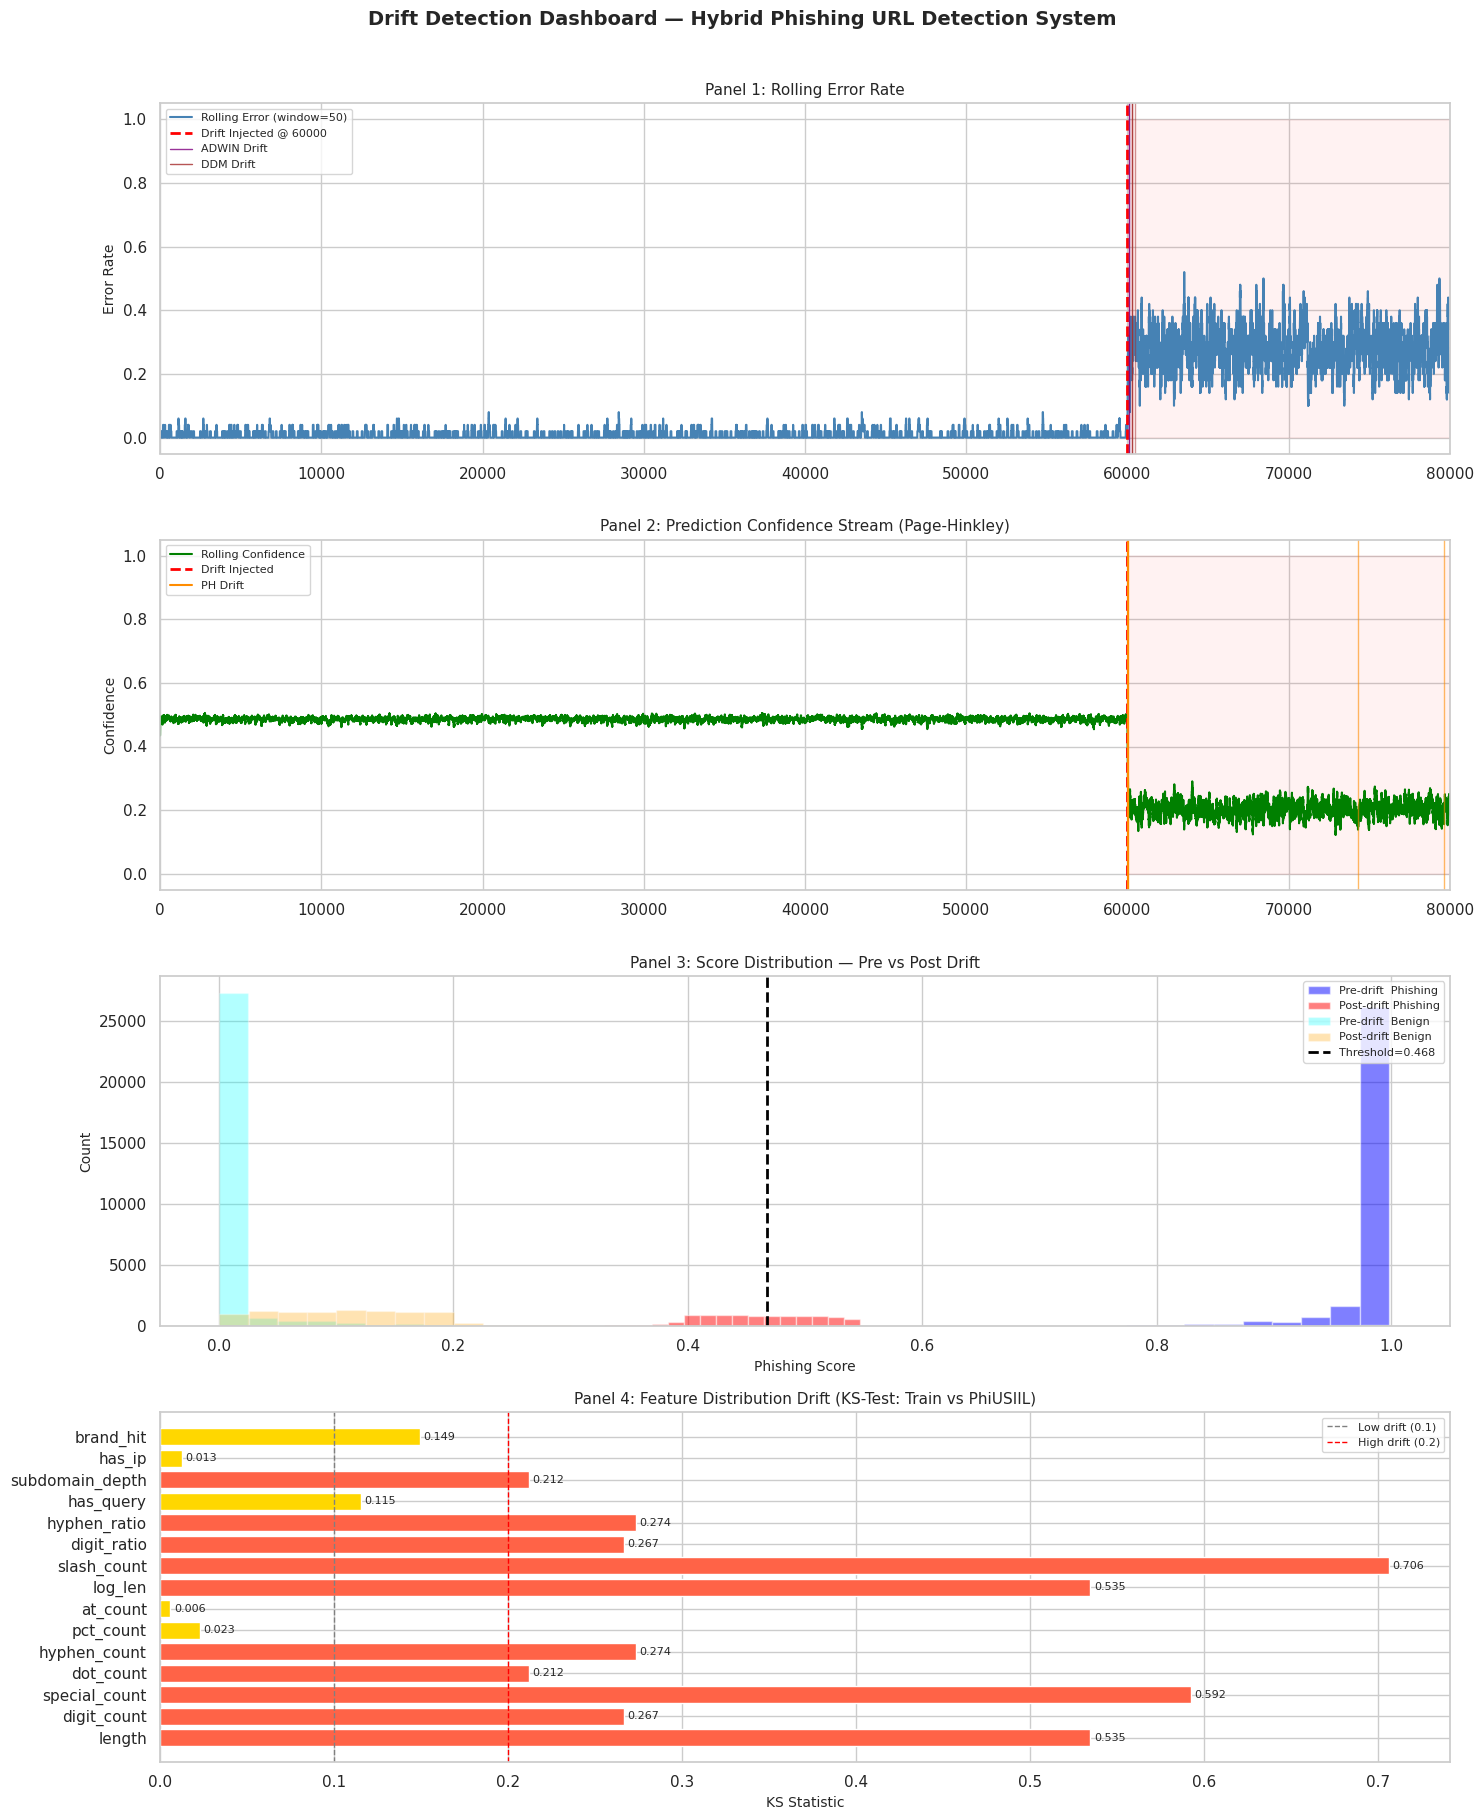

Saved → /content/drive/MyDrive/drift_detection_dashboard.png

================ STEP 11: ROLLING WINDOW ACCURACY ================


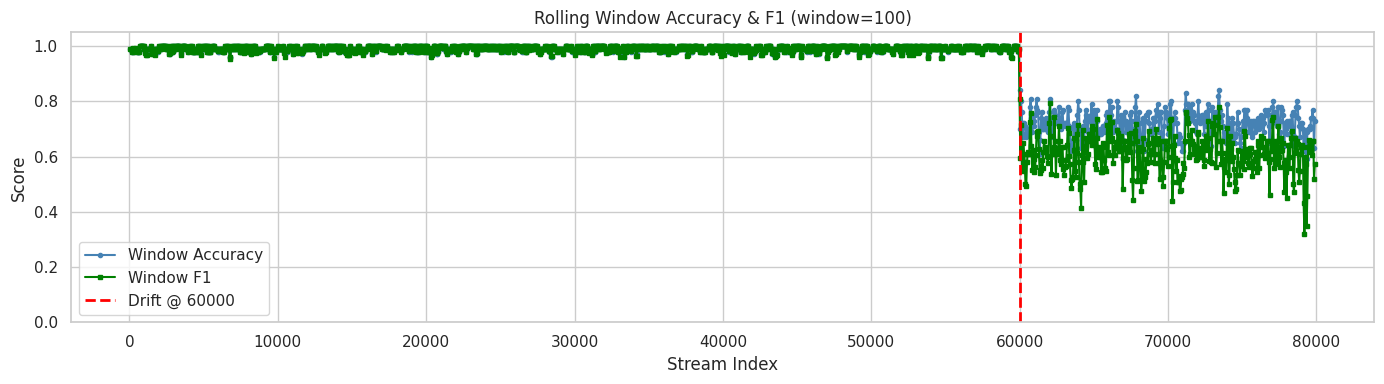

Saved → /content/drive/MyDrive/rolling_window_metrics.png

================ GRAPH 1: DATA EXPLORATION ================


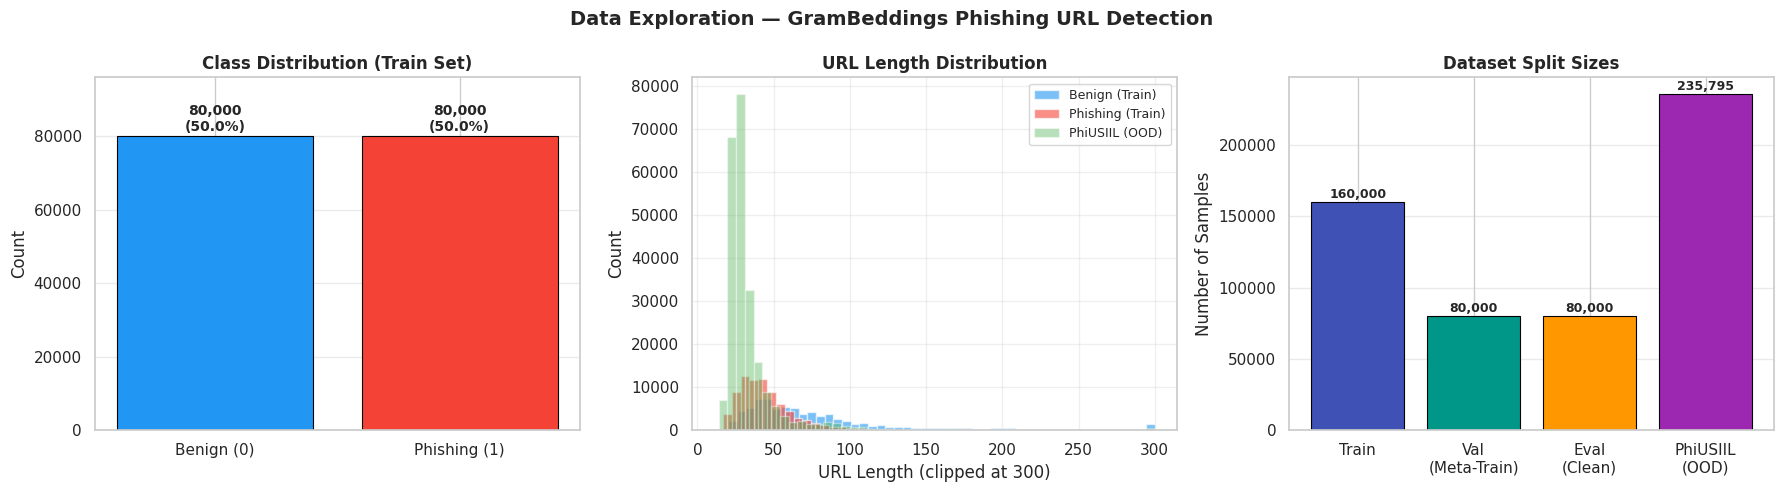

Saved → /content/drive/MyDrive/graph1_data_exploration.png

================ GRAPH 2: LEXICAL FEATURES ================


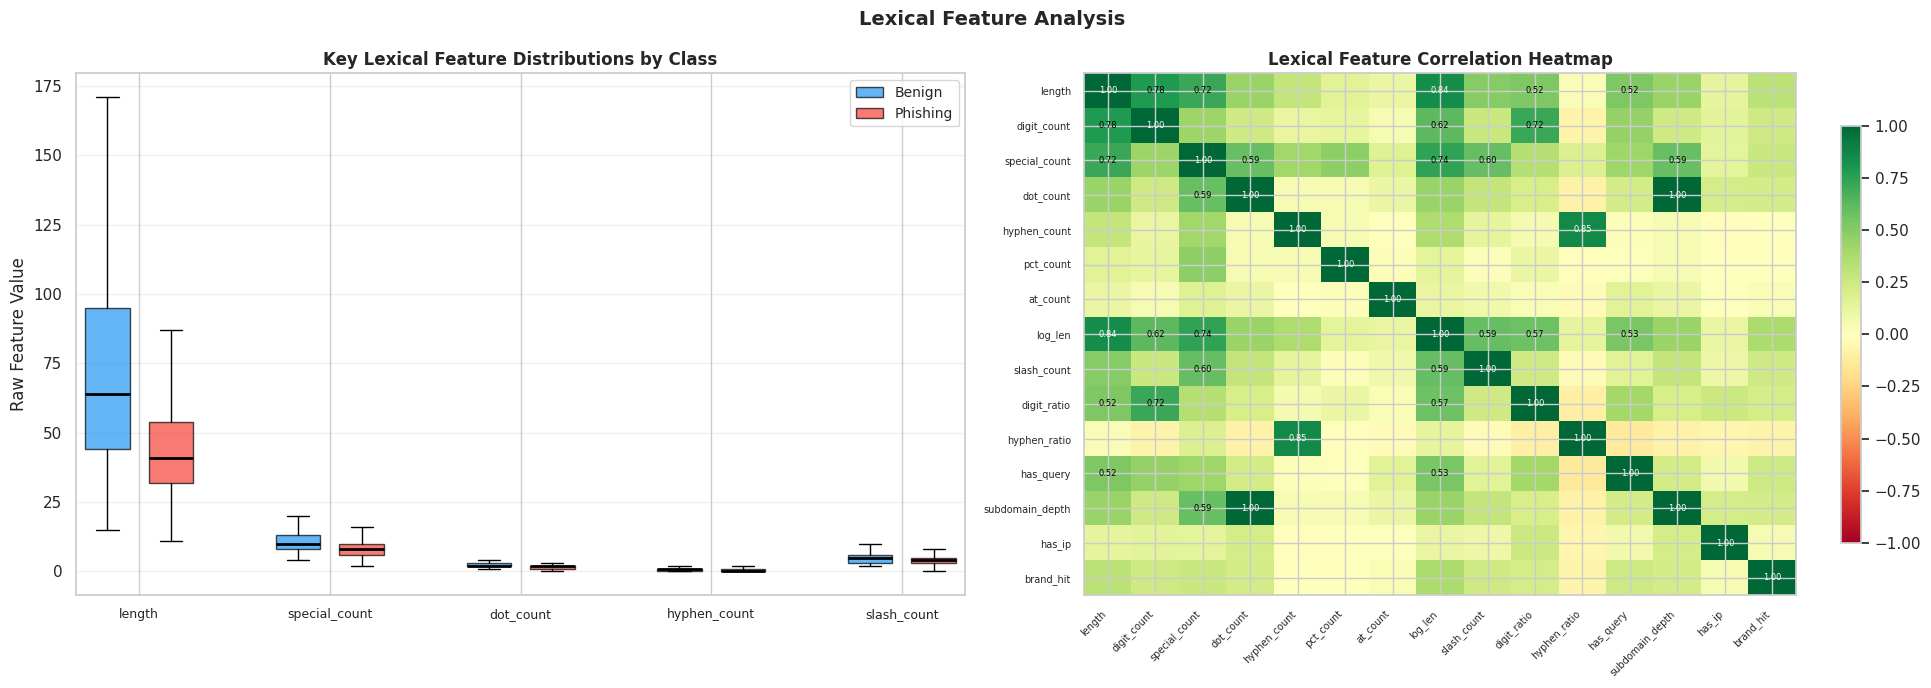

Saved → /content/drive/MyDrive/graph2_lexical_features.png

================ GRAPH 3: TCN TRAINING CURVES ================


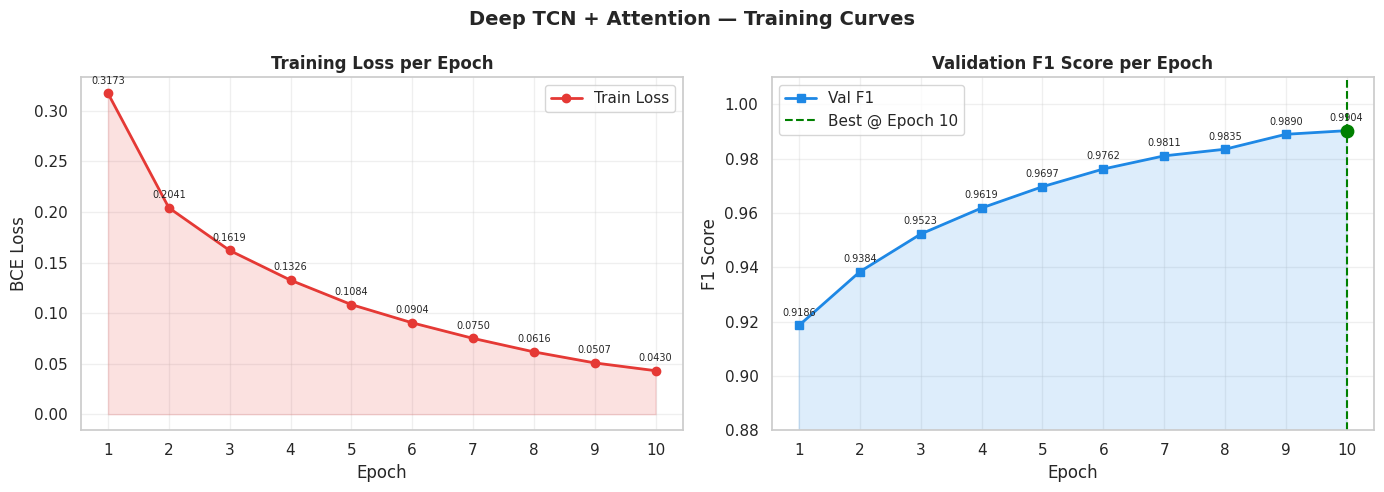

Saved → /content/drive/MyDrive/graph3_training_curves.png

================ GRAPH 4: ROC & PR CURVES ================


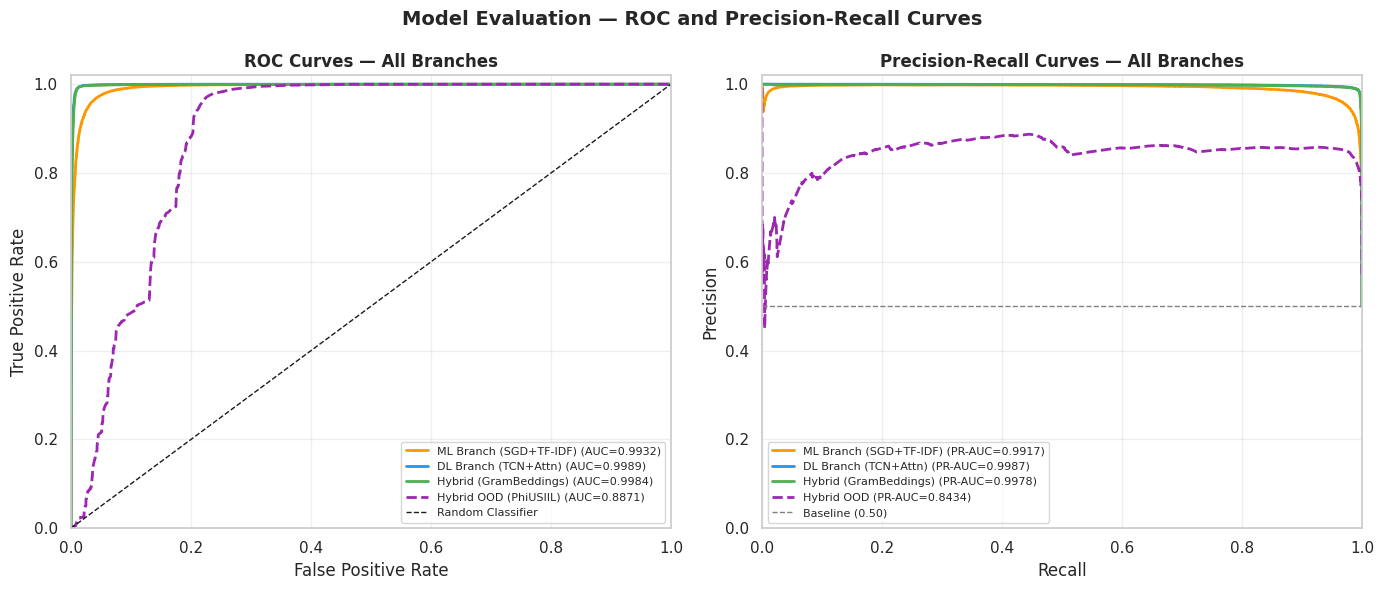

Saved → /content/drive/MyDrive/graph4_roc_pr_curves.png

================ GRAPH 5: CONFUSION MATRICES ================


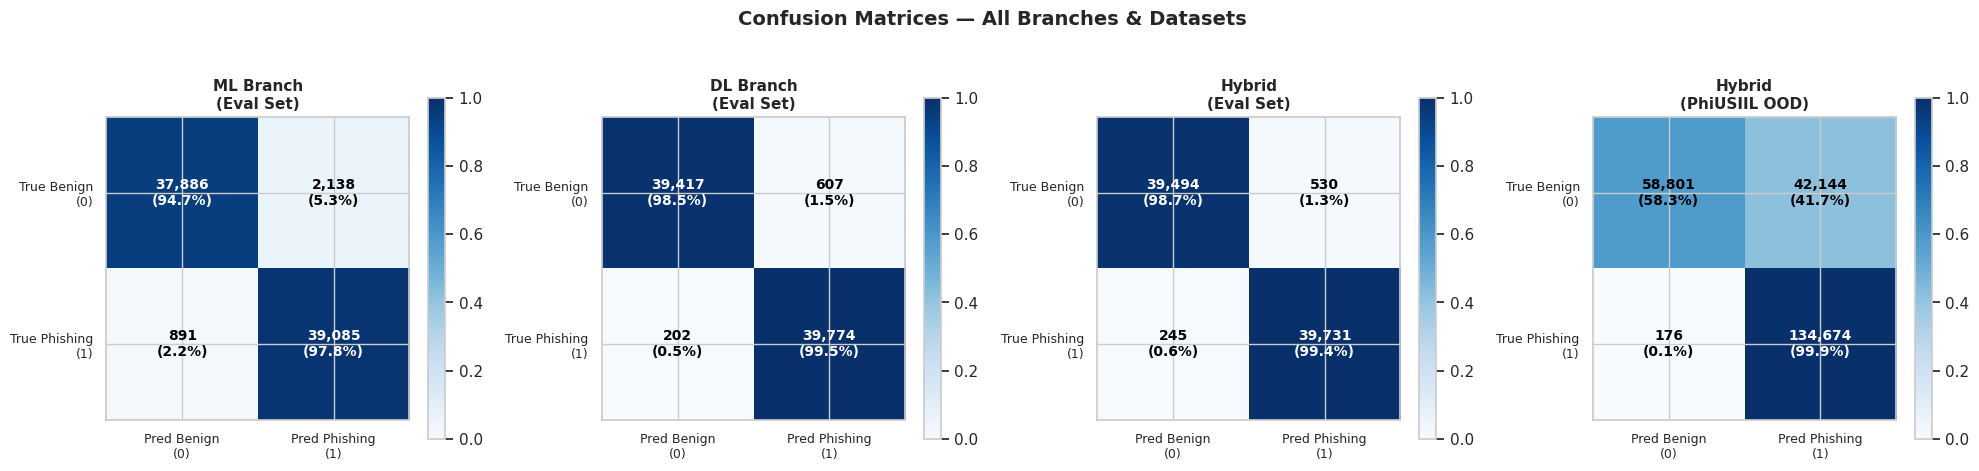

Saved → /content/drive/MyDrive/graph5_confusion_matrices.png

================ GRAPH 6: MODEL COMPARISON ================


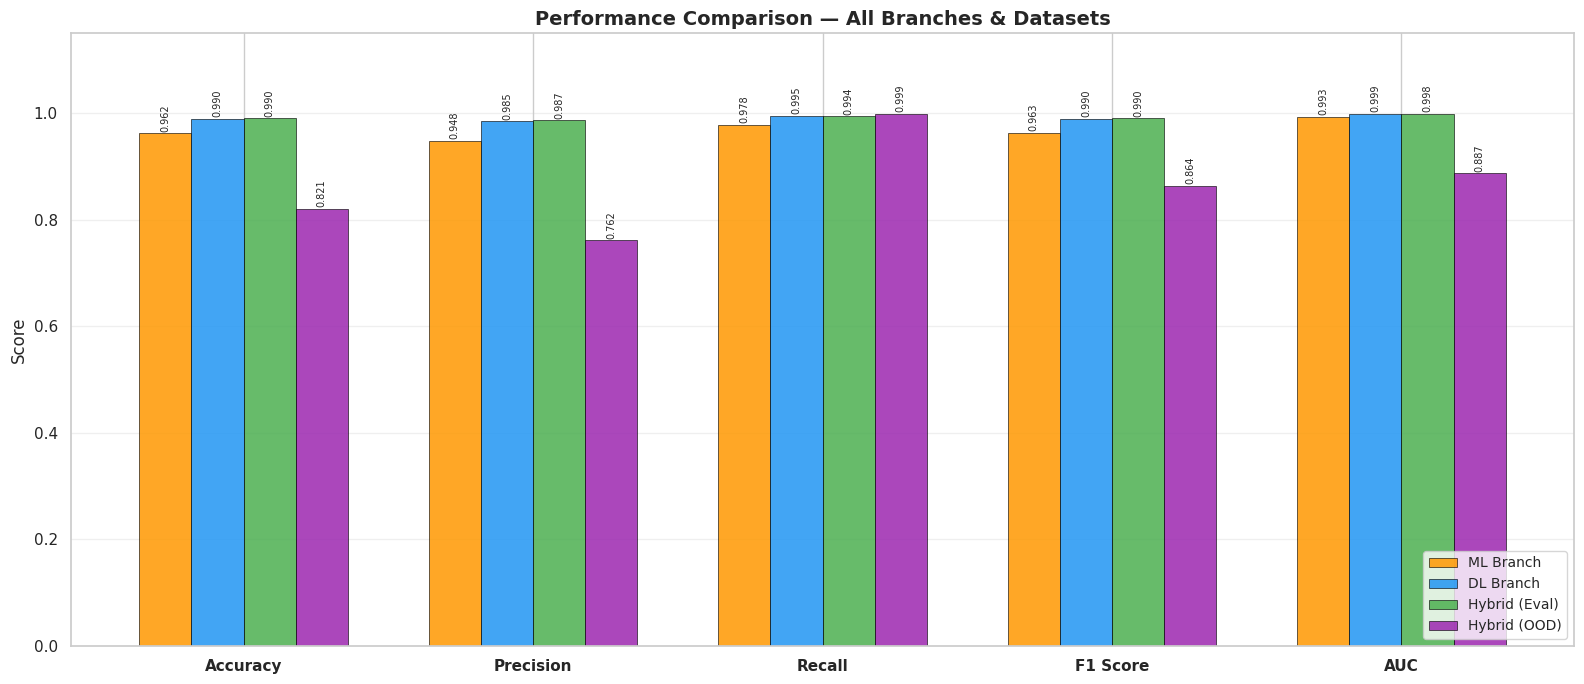

Saved → /content/drive/MyDrive/graph6_model_comparison.png

================ GRAPH 7: META-LEARNER & ANOMALY ================


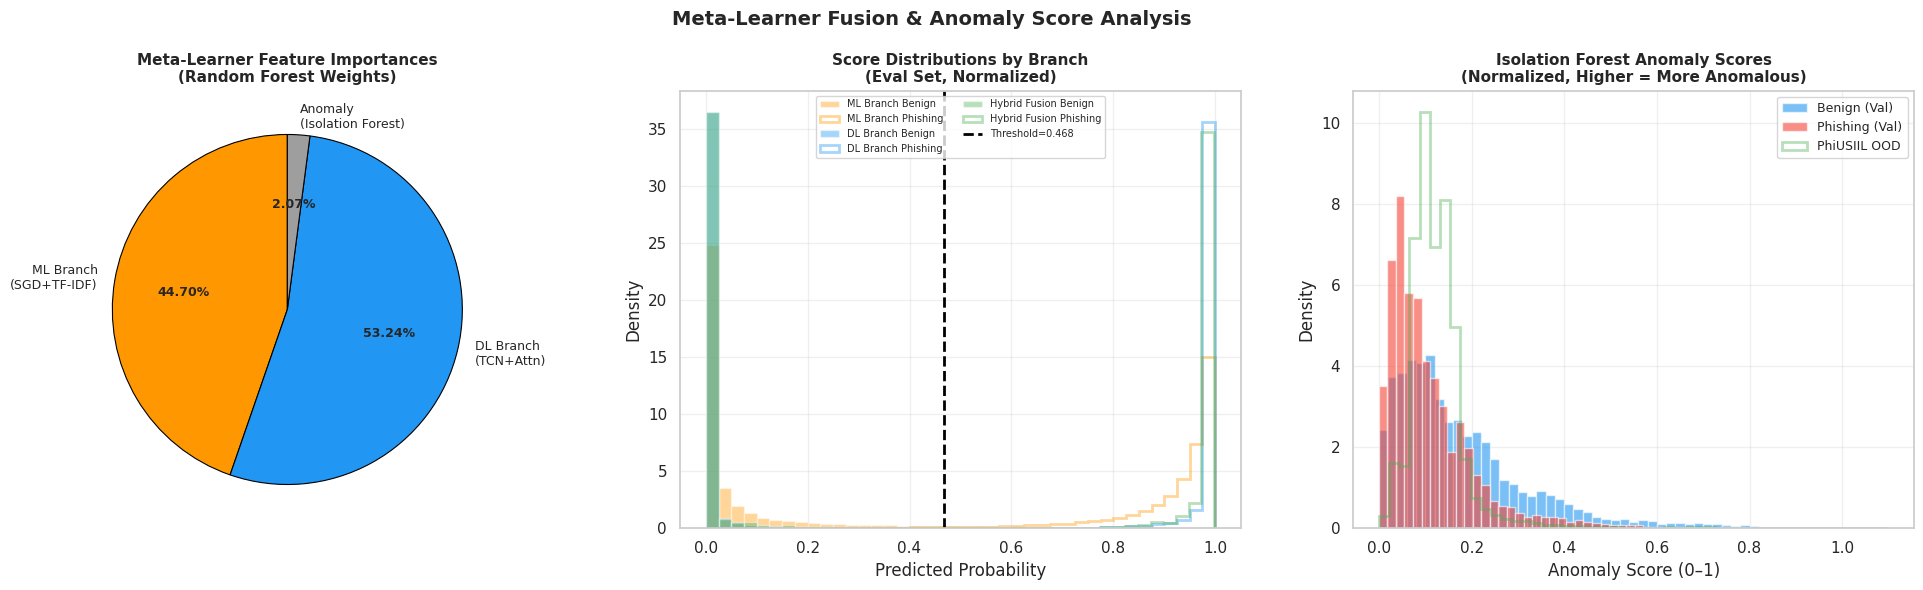

Saved → /content/drive/MyDrive/graph7_meta_anomaly_analysis.png

================ GRAPH 8: DETAILED DRIFT ANALYSIS ================


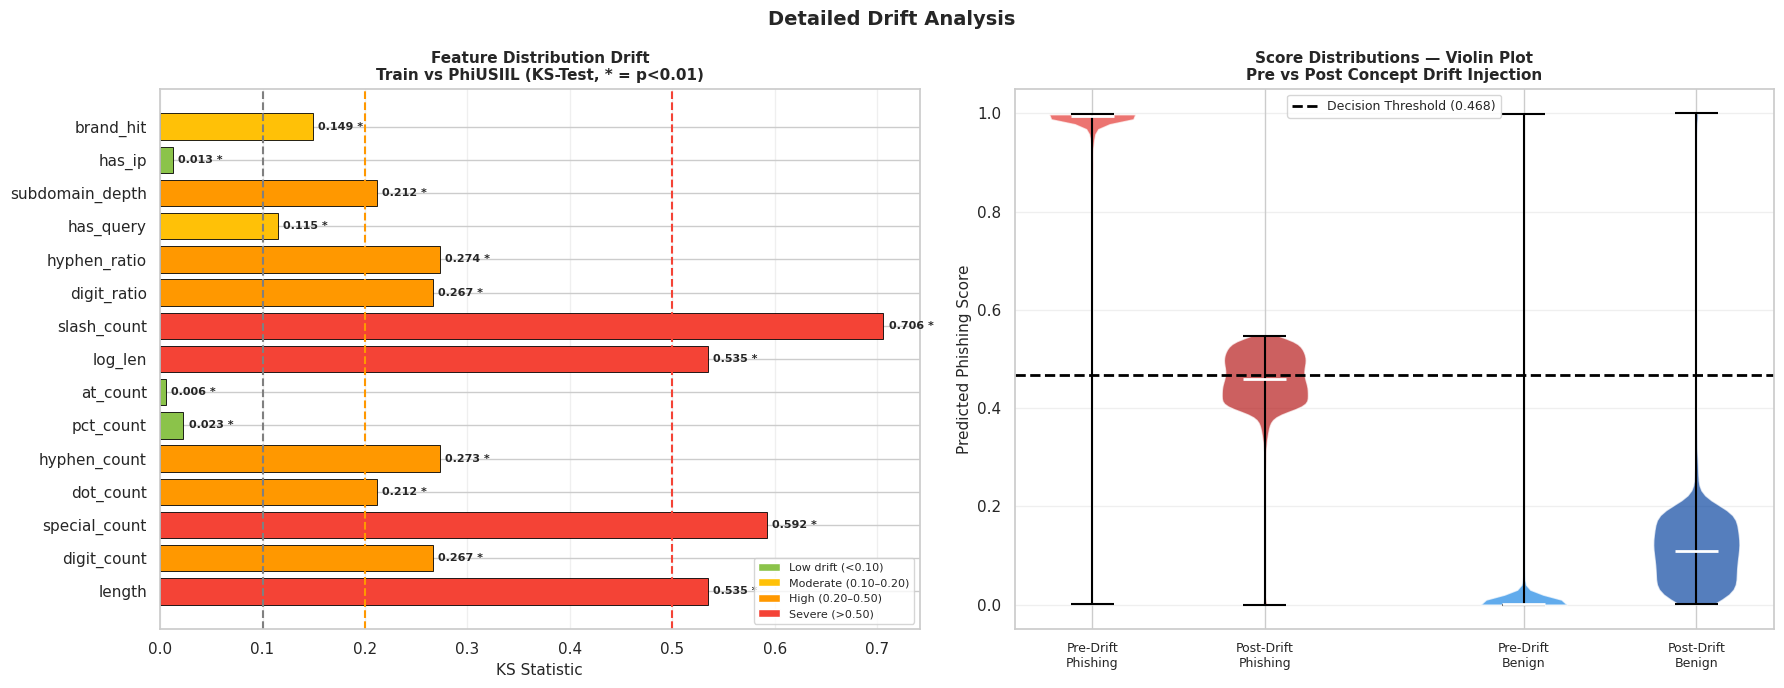

Saved → /content/drive/MyDrive/graph8_drift_detailed.png

================ GRAPH 9: THRESHOLD SENSITIVITY ================


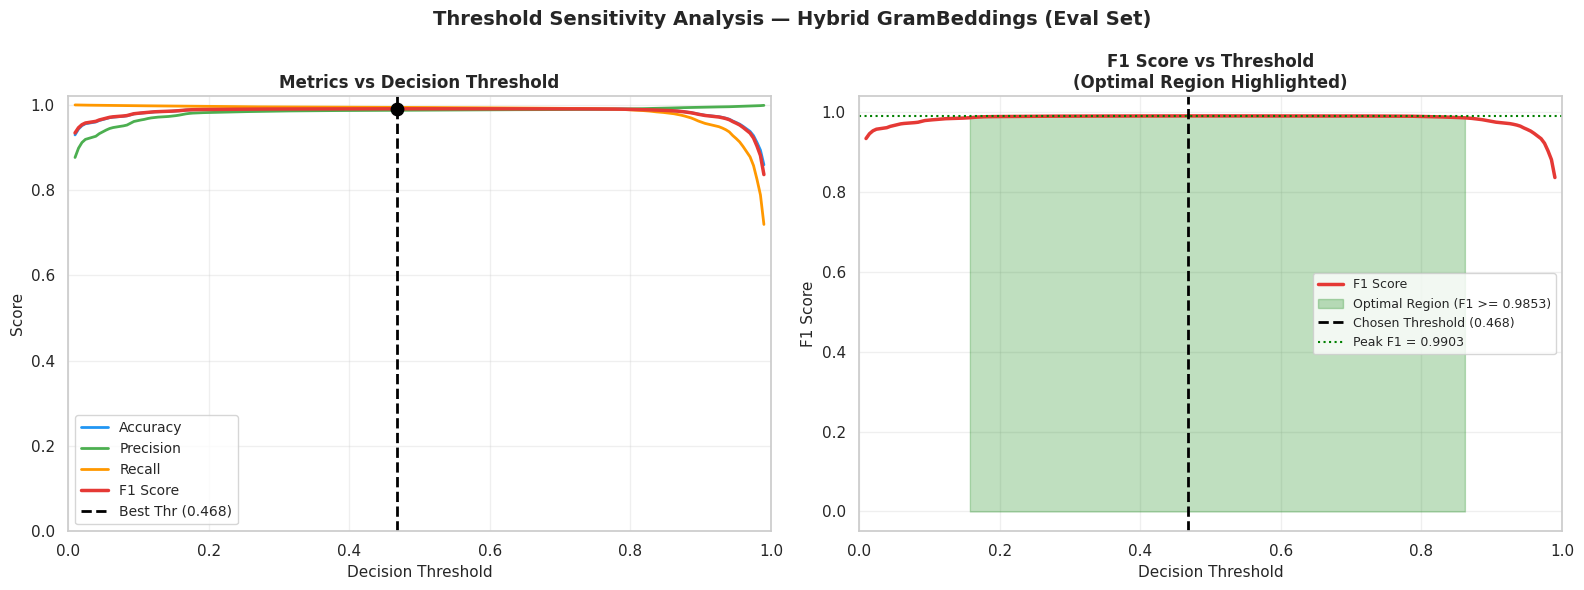

Saved → /content/drive/MyDrive/graph9_threshold_sensitivity.png

================ GRAPH 10: SUMMARY DASHBOARD ================


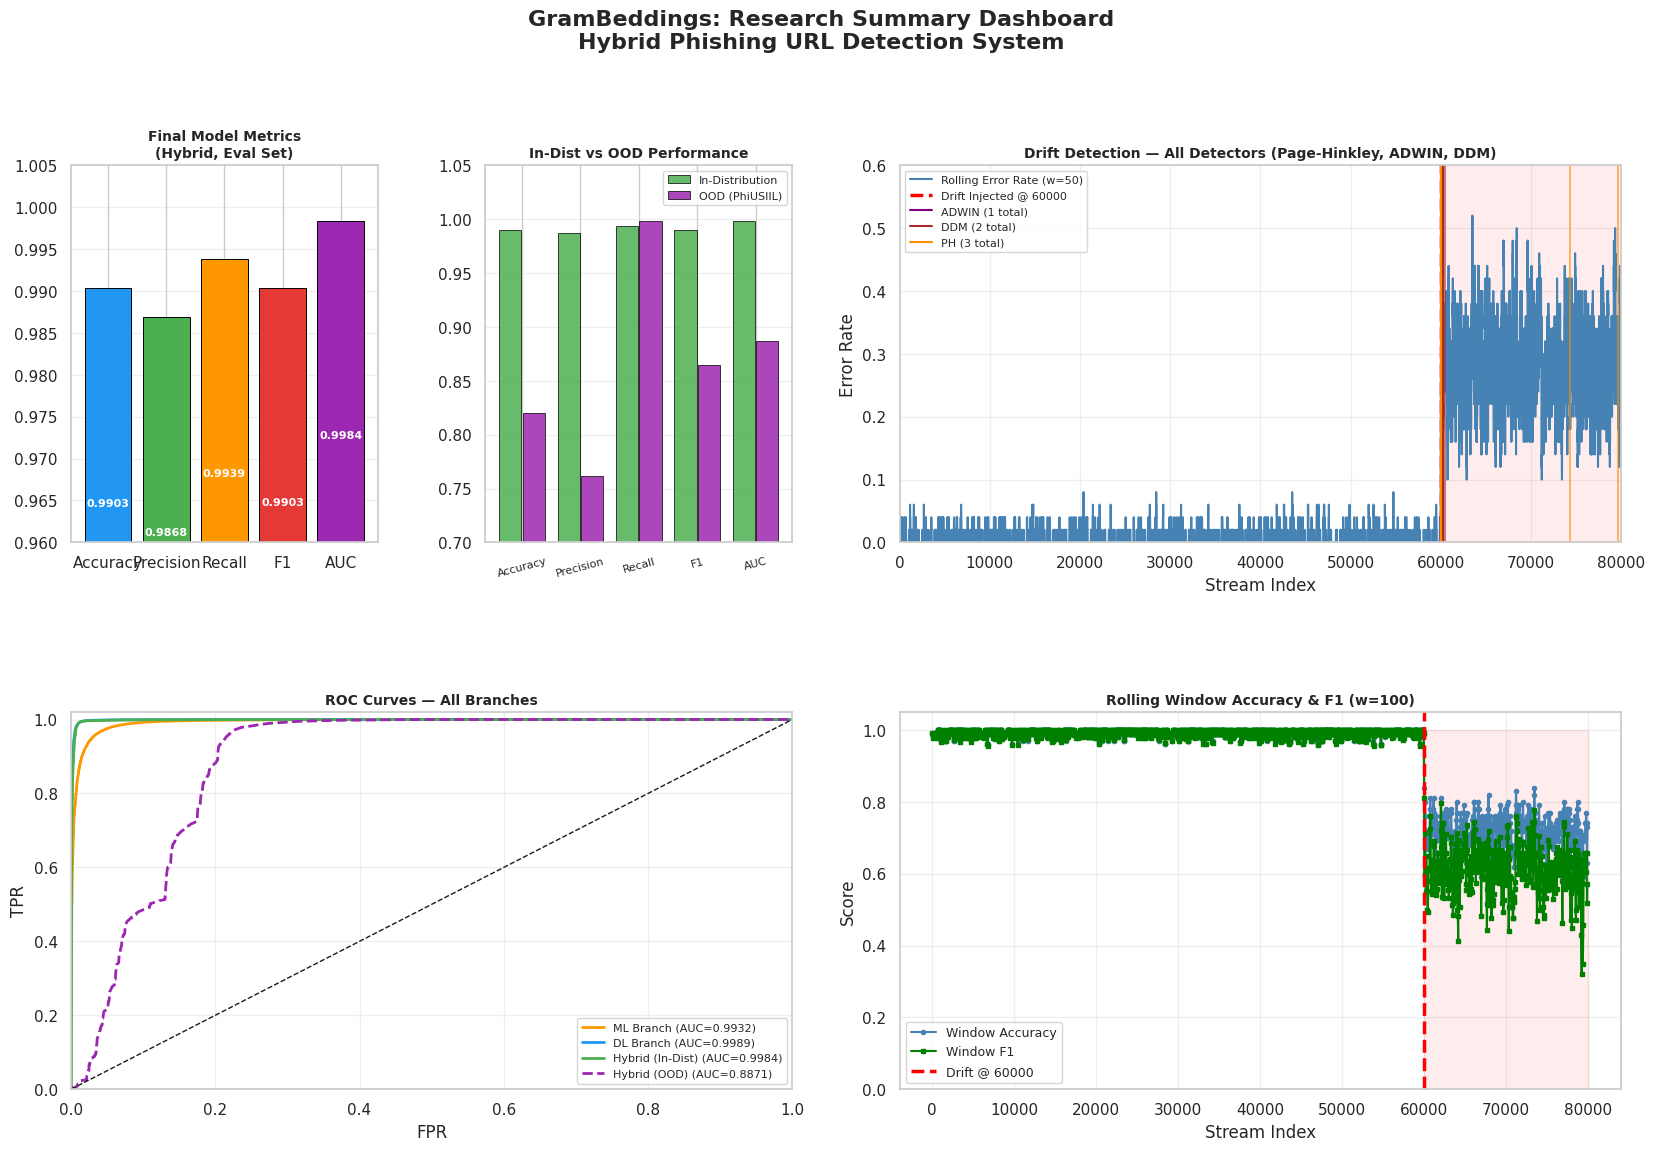

Saved → /content/drive/MyDrive/graph10_summary_dashboard.png

███████████████████████████████████████████████████████
  ACTIVE LEARNING LOOP WITH AUTOMATIC RETRAINING
███████████████████████████████████████████████████████

Config: budget=500, threshold=0.15, max_rounds=5


  DRIFT DETECTED at index 60091 → Retraining Round 1
  Queried 287 uncertain samples via oracle...
  Retraining ML branch...
    [ML]   partial_fit on 287 samples — done.
  Fine-tuning TCN+Attention...
    [DL]   Fine-tune epoch 1/2 | Loss: 0.3024
    [DL]   Fine-tune epoch 2/2 | Loss: 0.0986
  Recomputing val branch scores...
  Retraining meta-learner...
    [Meta] Random Forest retrained on 80000 samples.
  Re-scoring remaining stream...
    [Post-retrain round 1] Accuracy: 0.9880 | F1: 0.9879

  ACTIVE LEARNING LOOP COMPLETE
  Total retraining rounds : 1

  Round    Drift@     Queried    Post-Acc     Post-F1
  ----------------------------------------------------
  1        60091      287        0.9880       0.987

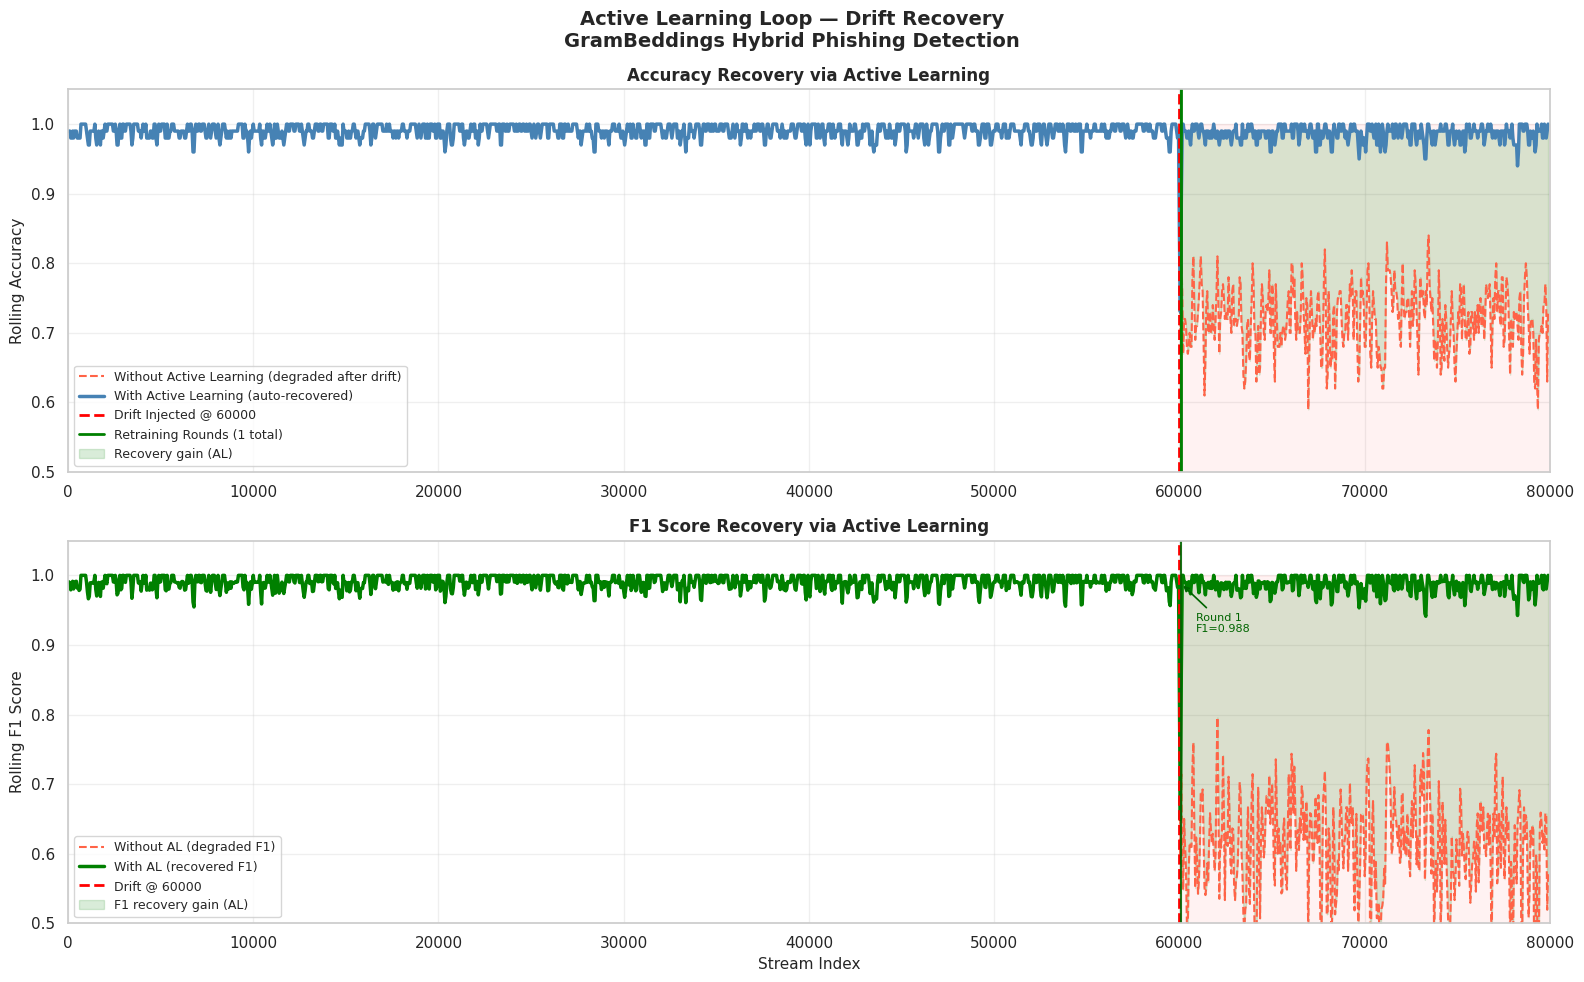

Saved → /content/drive/MyDrive/graph11_al_recovery.png

================ NEW GRAPH 12: AL ROUND ANALYSIS ================


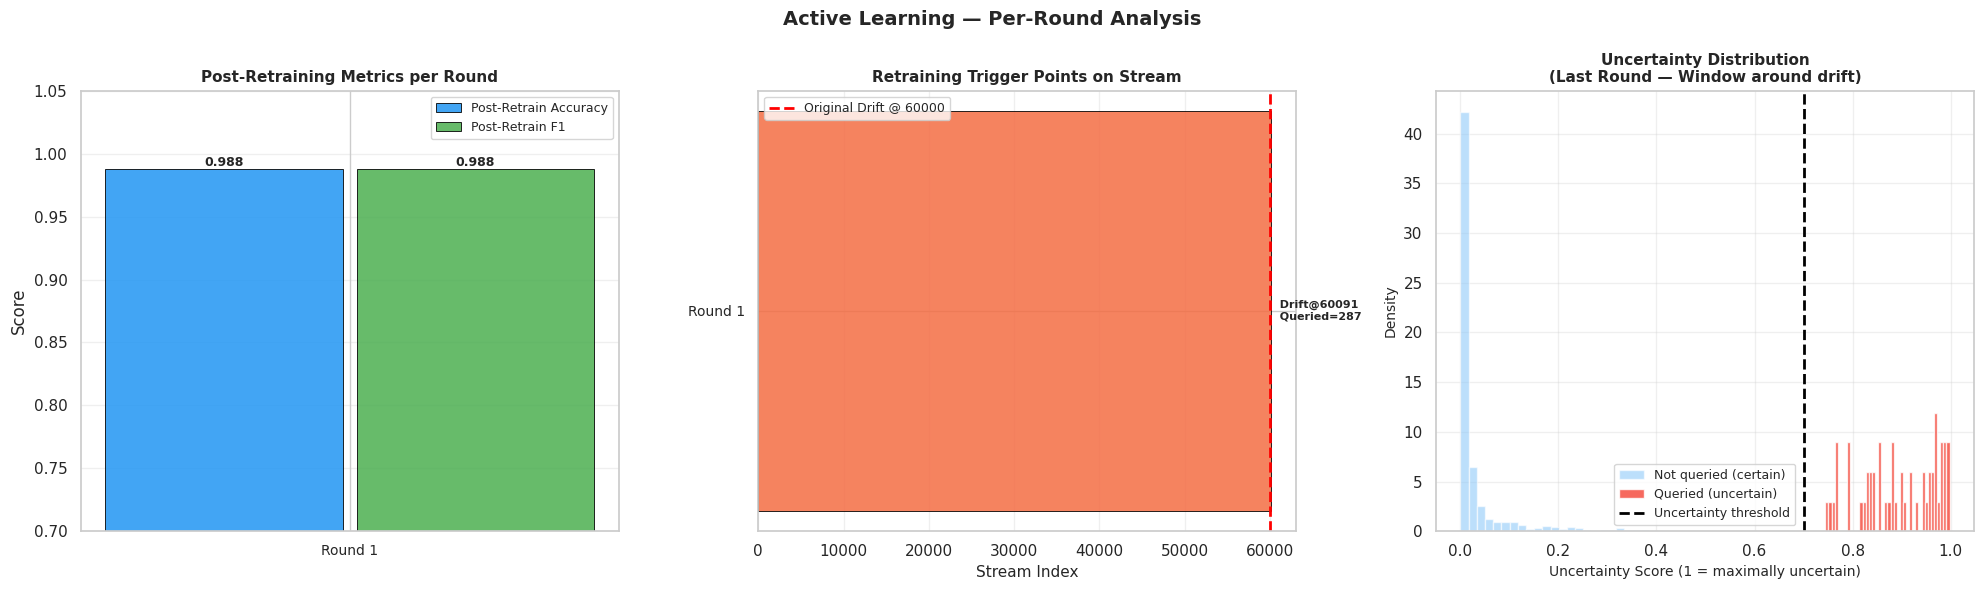

Saved → /content/drive/MyDrive/graph12_al_round_analysis.png

================ NEW GRAPH 13: SYSTEM COMPARISON DASHBOARD ================


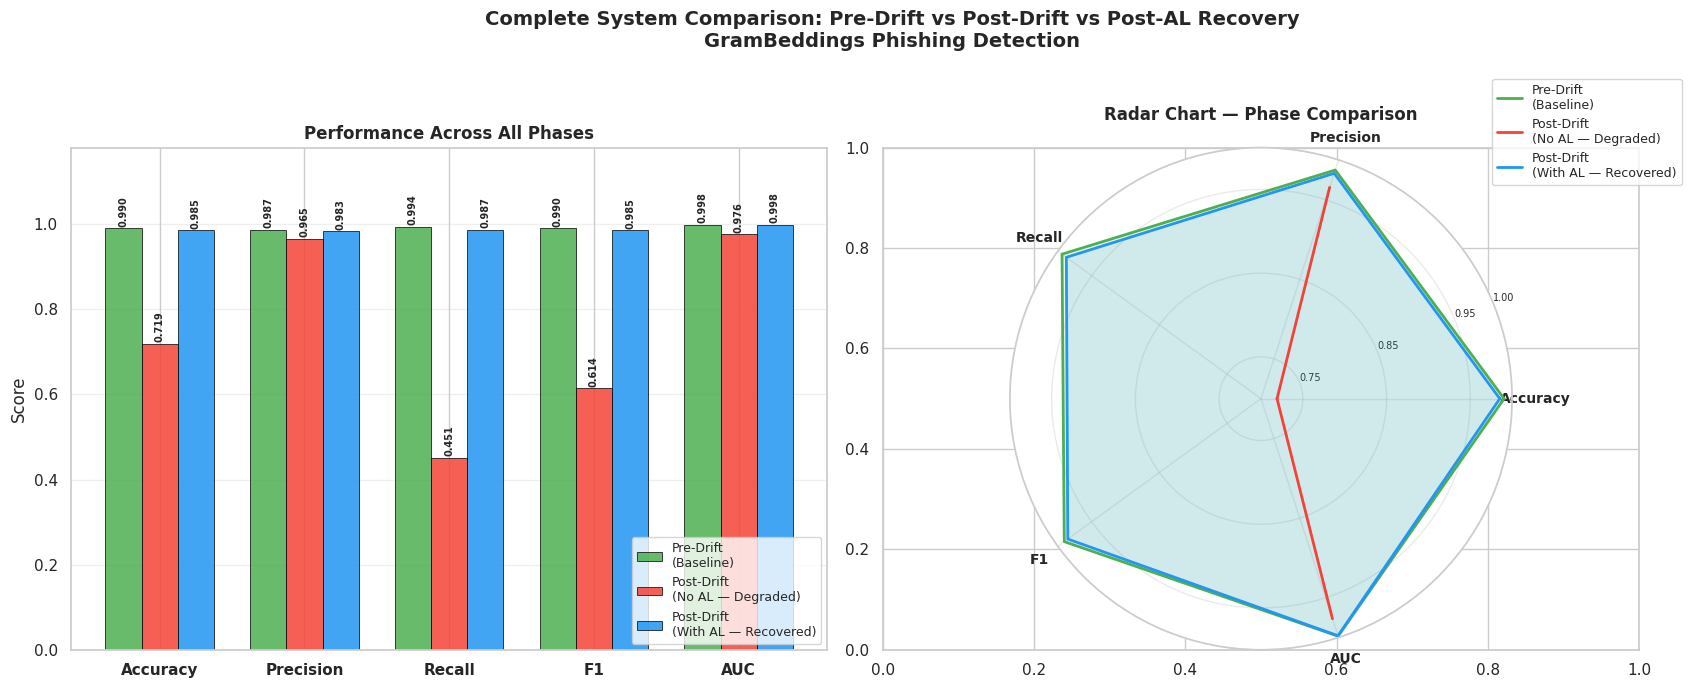

Saved → /content/drive/MyDrive/graph13_system_comparison.png

  FULL PIPELINE + ACTIVE LEARNING — COMPLETED
  Graphs saved to Google Drive:
    drift_detection_dashboard.png
    rolling_window_metrics.png
    graph1_data_exploration.png
    graph2_lexical_features.png
    graph3_training_curves.png
    graph4_roc_pr_curves.png
    graph5_confusion_matrices.png
    graph6_model_comparison.png
    graph7_meta_anomaly_analysis.png
    graph8_drift_detailed.png
    graph9_threshold_sensitivity.png
    graph10_summary_dashboard.png
    graph11_al_recovery.png          ← NEW
    graph12_al_round_analysis.png    ← NEW
    graph13_system_comparison.png    ← NEW

  Active Learning retraining rounds  : 1
  Total graphs produced              : 15


In [ ]:
# ==========================================================
# RESEARCH-GRADE HYBRID PHISHING URL DETECTION SYSTEM
# WITH ACTIVE LEARNING LOOP — FULL SINGLE CELL
# INCLUDES: All original graphs (1-10) + Drift Dashboard +
#           Active Learning Loop + New Graphs (11-13)
# ==========================================================

# ── MUST be the very first line ──
get_ipython().run_line_magic('matplotlib', 'inline')

import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['savefig.facecolor'] = 'white'

from IPython.display import display as ipy_display

print("\n================ STEP 0: SETUP ================")

from google.colab import drive
drive.mount("/content/drive")

import os, math, re, warnings, copy
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, auc, confusion_matrix
)
from scipy.sparse import hstack
from scipy.stats import ks_2samp

sns.set(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def save_and_show(path):
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    ipy_display(plt.gcf())
    plt.close()
    print(f"Saved → {path}")


# ==========================================================
print("\n================ STEP 1: DATA LOADING ================")

BASE = "/content/drive/MyDrive/data"

def load_data(path):
    df = pd.read_csv(path)
    if "URL" in df.columns:
        df = df.rename(columns={"URL": "url", "label": "labels"})
    df = df[["url", "labels"]].dropna()
    df["labels"] = df["labels"].astype(int)
    return df

train_df = load_data(os.path.join(BASE, "train.csv"))
test_df  = load_data(os.path.join(BASE, "test.csv"))
phi_df   = load_data(os.path.join(BASE, "phiusiil.csv"))

mid     = len(test_df) // 2
val_df  = test_df.iloc[:mid].reset_index(drop=True)
eval_df = test_df.iloc[mid:].reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape,  "<-- meta-learner training set")
print("Eval :", eval_df.shape, "<-- final clean evaluation")
print("PHI  :", phi_df.shape)

print("\nClass Distribution (Train)")
print(train_df.labels.value_counts(normalize=True))


# ==========================================================
print("\n================ STEP 2: LEXICAL FEATURES (15 FEATURES) ================")

BRAND_KEYWORDS = [
    'secure', 'login', 'verify', 'account', 'update',
    'bank', 'paypal', 'amazon', 'apple', 'microsoft'
]

def lexical_features(url):
    u = str(url).lower()
    length          = len(u)
    digit_count     = sum(c.isdigit() for c in u)
    special_count   = sum(not c.isalnum() for c in u)
    dot_count       = u.count('.')
    hyphen_count    = u.count('-')
    pct_count       = u.count('%')
    at_count        = u.count('@')
    log_len         = math.log2(length + 1)
    slash_count     = u.count('/')
    digit_ratio     = digit_count / (length + 1)
    hyphen_ratio    = hyphen_count / (length + 1)
    has_query       = int('?' in u)
    subdomain_depth = max(0, dot_count - 1)
    has_ip          = int(bool(re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', u)))
    brand_hit       = int(any(kw in u for kw in BRAND_KEYWORDS))
    return [
        length, digit_count, special_count, dot_count, hyphen_count,
        pct_count, at_count, log_len,
        slash_count, digit_ratio, hyphen_ratio, has_query,
        subdomain_depth, has_ip, brand_hit
    ]

LEX_NAMES = [
    "length", "digit_count", "special_count", "dot_count", "hyphen_count",
    "pct_count", "at_count", "log_len", "slash_count", "digit_ratio",
    "hyphen_ratio", "has_query", "subdomain_depth", "has_ip", "brand_hit"
]

X_lex_train_raw = np.array([lexical_features(u) for u in train_df.url])
X_lex_val_raw   = np.array([lexical_features(u) for u in val_df.url])
X_lex_eval_raw  = np.array([lexical_features(u) for u in eval_df.url])
X_lex_phi_raw   = np.array([lexical_features(u) for u in phi_df.url])

X_lex_train = X_lex_train_raw.copy()
X_lex_val   = X_lex_val_raw.copy()
X_lex_eval  = X_lex_eval_raw.copy()
X_lex_phi   = X_lex_phi_raw.copy()

scaler_lex  = StandardScaler()
X_lex_train = scaler_lex.fit_transform(X_lex_train)
X_lex_val   = scaler_lex.transform(X_lex_val)
X_lex_eval  = scaler_lex.transform(X_lex_eval)
X_lex_phi   = scaler_lex.transform(X_lex_phi)

print(f"Lexical feature dim: {X_lex_train.shape[1]}")


# ==========================================================
print("\n================ STEP 3: TF-IDF FEATURES (80K vocab) ================")

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 6),
    min_df=2,
    max_features=80000,
    sublinear_tf=True,
)

X_ng_train = tfidf.fit_transform(train_df.url)
X_ng_val   = tfidf.transform(val_df.url)
X_ng_eval  = tfidf.transform(eval_df.url)
X_ng_phi   = tfidf.transform(phi_df.url)

print("TF-IDF Feature Dimension:", X_ng_train.shape[1])

X_train_ml = hstack([X_ng_train, X_lex_train]).tocsr()
X_val_ml   = hstack([X_ng_val,   X_lex_val  ]).tocsr()
X_eval_ml  = hstack([X_ng_eval,  X_lex_eval ]).tocsr()
X_phi_ml   = hstack([X_ng_phi,   X_lex_phi  ]).tocsr()

print("Final ML Feature Size:", X_train_ml.shape[1])


# ==========================================================
print("\n================ STEP 4: ONLINE ML MODEL (SGD) ================")

clf = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    alpha=1e-5,
    max_iter=1000,
    tol=1e-4,
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train_ml, train_df.labels)

p_ml_val  = clf.predict_proba(X_val_ml)[:, 1]
p_ml_eval = clf.predict_proba(X_eval_ml)[:, 1]
p_ml_phi  = clf.predict_proba(X_phi_ml)[:, 1]

print("ML branch trained.")


# ==========================================================
print("\n================ STEP 5: ISOLATION FOREST ================")

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples='auto',
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_lex_train[train_df.labels.values == 0])

a_val  = -iso.score_samples(X_lex_val)
a_eval = -iso.score_samples(X_lex_eval)
a_phi  = -iso.score_samples(X_lex_phi)

scaler_anom = MinMaxScaler()
a_val  = scaler_anom.fit_transform(a_val.reshape(-1, 1)).flatten()
a_eval = scaler_anom.transform(a_eval.reshape(-1, 1)).flatten()
a_phi  = scaler_anom.transform(a_phi.reshape(-1, 1)).flatten()

print("Isolation Forest trained.")


# ==========================================================
print("\n================ STEP 6: DEEP TCN + ATTENTION ================")

MAX_LEN = 200

chars    = sorted(set("".join(train_df.url.astype(str))))
char2idx = {c: i + 1 for i, c in enumerate(chars)}
char2idx["<PAD>"] = 0

def encode(u):
    s = [char2idx.get(c, 0) for c in str(u)[:MAX_LEN]]
    return s + [0] * (MAX_LEN - len(s))

class URLDS(Dataset):
    def __init__(self, urls, y):
        self.X = [encode(u) for u in urls]
        self.y = y.values if hasattr(y, 'values') else list(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i], dtype=torch.float)

train_dl = DataLoader(URLDS(train_df.url, train_df.labels), batch_size=512, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(URLDS(val_df.url,   val_df.labels),   batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
eval_dl  = DataLoader(URLDS(eval_df.url,  eval_df.labels),  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
phi_dl   = DataLoader(URLDS(phi_df.url,   phi_df.labels),   batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

class DeepTCN(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.emb     = nn.Embedding(vocab_size, 128, padding_idx=0)
        self.conv1   = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.conv2   = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.conv3   = nn.Conv1d(256, 128, kernel_size=3, padding=1)
        self.bn      = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.4)
        self.attn    = nn.Linear(128, 1)
        self.fc1     = nn.Linear(128, 64)
        self.fc2     = nn.Linear(64, 1)

    def forward(self, x):
        x   = self.emb(x).transpose(1, 2)
        x   = torch.relu(self.conv1(x))
        x   = torch.relu(self.conv2(x))
        x   = torch.relu(self.conv3(x))
        x   = self.bn(x)
        x   = self.dropout(x).transpose(1, 2)
        w   = torch.softmax(self.attn(x).squeeze(-1), dim=1)
        ctx = (x * w.unsqueeze(-1)).sum(1)
        out = torch.relu(self.fc1(ctx))
        # Use squeeze(1) instead of squeeze() to avoid collapsing batch-size-1
        return self.fc2(out).squeeze(1)

model = DeepTCN(len(char2idx)).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

opt   = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
lossf = nn.BCEWithLogitsLoss()
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10, eta_min=1e-5)

best_f1    = 0
best_state = None
epoch_losses = []
epoch_val_f1 = []

for e in range(10):
    model.train()
    total_loss = 0
    for X, y in train_dl:
        X, y = X.to(device), y.to(device)
        opt.zero_grad()
        loss = lossf(model(X), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total_loss += loss.item()
    sched.step()

    model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for X, y in val_dl:
            probs = torch.sigmoid(model(X.to(device))).cpu().numpy()
            val_preds.extend(probs)
            val_true.extend(y.numpy())
    val_f1 = f1_score(val_true, (np.array(val_preds) > 0.5).astype(int))
    epoch_losses.append(total_loss / len(train_dl))
    epoch_val_f1.append(val_f1)
    if val_f1 > best_f1:
        best_f1    = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f"Epoch {e+1:2d} | Loss: {total_loss/len(train_dl):.4f} | Val F1: {val_f1:.4f}")

model.load_state_dict(best_state)
print(f"\nLoaded best checkpoint — Val F1: {best_f1:.4f}")

def dl_scores(dl, net=None):
    if net is None:
        net = model
    net.eval()
    s = []
    with torch.no_grad():
        for X, _ in dl:
            s.extend(torch.sigmoid(net(X.to(device))).cpu().numpy())
    return np.array(s)

p_dl_val  = dl_scores(val_dl)
p_dl_eval = dl_scores(eval_dl)
p_dl_phi  = dl_scores(phi_dl)


# ==========================================================
print("\n================ STEP 7-9: FUSION + META (NO LEAKAGE) ================")

meta_X_val  = np.column_stack([p_ml_val,  p_dl_val,  a_val])
meta_X_eval = np.column_stack([p_ml_eval, p_dl_eval, a_eval])

meta_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
meta_clf.fit(meta_X_val, val_df.labels)

print("Meta-learner feature importances [ML, DL, Anomaly]:")
print(np.round(meta_clf.feature_importances_, 4))

S_eval = meta_clf.predict_proba(meta_X_eval)[:, 1]
S_phi  = meta_clf.predict_proba(np.column_stack([p_ml_phi, p_dl_phi, a_phi]))[:, 1]

prec, rec, thr = precision_recall_curve(eval_df.labels, S_eval)
f1_arr   = 2 * prec * rec / (prec + rec + 1e-9)
best_thr = thr[np.argmax(f1_arr)]
print(f"\nBest Threshold: {best_thr:.4f}")

yhat_eval = (S_eval > best_thr).astype(int)
yhat_phi  = (S_phi  > best_thr).astype(int)

def print_metrics(y, yhat, s, name):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {accuracy_score(y, yhat):.6f}")
    print(f"  Precision: {precision_score(y, yhat):.6f}")
    print(f"  Recall   : {recall_score(y, yhat):.6f}")
    print(f"  F1 Score : {f1_score(y, yhat):.6f}")
    fpr, tpr, _ = roc_curve(y, s)
    print(f"  AUC      : {auc(fpr, tpr):.6f}")

print_metrics(eval_df.labels, (p_ml_eval > 0.5).astype(int), p_ml_eval, "ML Branch")
print_metrics(eval_df.labels, (p_dl_eval > 0.5).astype(int), p_dl_eval, "DL Branch")
print_metrics(eval_df.labels, yhat_eval, S_eval, "HYBRID — GramBeddings (Final)")
print_metrics(phi_df.labels,  yhat_phi,  S_phi,  "HYBRID — PhiUSIIL (Out-of-Distribution)")


# ==========================================================
print("\n================ STEP 10: DRIFT DETECTION (ENHANCED) ================")

class PageHinkley:
    def __init__(self, delta=0.005, lam=8):
        self.delta = delta
        self.lam   = lam
        self.reset()

    def reset(self):
        self.mean    = 0
        self.sum     = 0
        self.min_val = 0
        self.t       = 0

    def update(self, x):
        self.t   += 1
        self.mean += (x - self.mean) / self.t
        self.sum  += x - self.mean - self.delta
        self.min_val = min(self.min_val, self.sum)
        if self.sum - self.min_val > self.lam:
            self.reset()
            return True
        return False


class ADWIN:
    def __init__(self, delta=0.002, min_window=30, max_window=1000):
        self.delta      = delta
        self.min_window = min_window
        self.max_window = max_window
        self.window     = []

    def update(self, x):
        self.window.append(x)
        if len(self.window) > self.max_window:
            self.window = self.window[-self.max_window:]
        if len(self.window) < self.min_window * 2:
            return False
        W = np.array(self.window)
        n = len(W)
        for split in range(self.min_window, n - self.min_window):
            n0, n1   = split, n - split
            mu0, mu1 = W[:split].mean(), W[split:].mean()
            eps_cut  = np.sqrt((1 / (2 * n0) + 1 / (2 * n1)) * np.log(4 * n / self.delta))
            if abs(mu0 - mu1) >= eps_cut:
                self.window = list(W[split:])
                return True
        return False


class DDM:
    def __init__(self, warning_level=2.0, drift_level=3.0):
        self.warning_level = warning_level
        self.drift_level   = drift_level
        self.reset()

    def reset(self):
        self.n     = 1
        self.p     = 1
        self.s     = 0
        self.p_min = float('inf')
        self.s_min = float('inf')

    def update(self, error):
        self.n += 1
        self.p  = self.p + (error - self.p) / self.n
        self.s  = np.sqrt(max(self.p * (1 - self.p) / self.n, 1e-12))
        if self.p + self.s < self.p_min + self.s_min:
            self.p_min = self.p
            self.s_min = self.s
        if self.s_min < 1e-9:
            return "NORMAL"
        level = (self.p + self.s - self.p_min - self.s_min) / self.s_min
        if level > self.drift_level:
            self.reset()
            return "DRIFT"
        elif level > self.warning_level:
            return "WARNING"
        return "NORMAL"


def detect_feature_drift(X_ref, X_new, feature_names, alpha=0.01):
    drifted = []
    for i, name in enumerate(feature_names):
        stat, p = ks_2samp(X_ref[:, i], X_new[:, i])
        if p < alpha:
            drifted.append((name, round(stat, 4), round(p, 6)))
    return drifted

print("\n[Feature Distribution Drift — Train vs PhiUSIIL (OOD)]")
feature_drifts = detect_feature_drift(X_lex_train, X_lex_phi, LEX_NAMES)
if feature_drifts:
    for fname, stat, pval in feature_drifts:
        print(f"  ⚠  DRIFT in '{fname}': KS={stat}, p={pval}")
else:
    print("  No significant feature drift detected.")

print("\n[Simulating Concept Drift — Adversarial Score Injection]")

n_eval      = len(eval_df)
drift_start = int(n_eval * 0.75)
noise_scale = 0.45

S_eval_sim = S_eval.copy()
rng = np.random.default_rng(42)

for i in range(drift_start, n_eval):
    if eval_df.labels.iloc[i] == 1:
        S_eval_sim[i] = max(0.0, S_eval[i] - rng.uniform(noise_scale, 0.6))
    else:
        S_eval_sim[i] = min(1.0, S_eval[i] + rng.uniform(0.0, 0.2))

yhat_sim = (S_eval_sim > best_thr).astype(int)
print(f"  Drift injected from index {drift_start} to {n_eval-1}")

ph2   = PageHinkley(delta=0.005, lam=8)
adwin = ADWIN(delta=0.002, min_window=30, max_window=1000)
ddm   = DDM(warning_level=2.0, drift_level=3.0)

WINDOW         = 50
ph_drifts      = []
adwin_drifts   = []
ddm_drifts     = []
ddm_warnings   = []
rolling_errors = []
conf_stream    = []

print("  Running drift detection loop...")
for i in range(n_eval):
    if i % 10000 == 0:
        print(f"    [{i}/{n_eval}] processed...")
    true_label = eval_df.labels.iloc[i]
    pred_label = yhat_sim[i]
    score      = S_eval_sim[i]
    err        = int(pred_label != true_label)

    conf = abs(score - best_thr)
    conf_stream.append(conf)
    rolling_errors.append(err)

    if ph2.update(1 - conf):
        ph_drifts.append(i)

    if adwin.update(float(err)):
        adwin_drifts.append(i)

    status = ddm.update(err)
    if status == "DRIFT":
        ddm_drifts.append(i)
    elif status == "WARNING":
        ddm_warnings.append(i)

print(f"  Drift detection loop complete.")

print(f"\n{'='*55}")
print(f"  DRIFT DETECTION SUMMARY")
print(f"{'='*55}")
print(f"  Drift injected at index        : {drift_start}")
print(f"  Page-Hinkley (confidence-based): {len(ph_drifts):>4} drift(s)   {ph_drifts[:8]}")
print(f"  ADWIN        (error-based)     : {len(adwin_drifts):>4} drift(s)   {adwin_drifts[:8]}")
print(f"  DDM          (error-based)     : {len(ddm_drifts):>4} drift(s)   {ddm_drifts[:8]}")
print(f"  DDM          Warnings          : {len(ddm_warnings):>4}")
print(f"  KS-Test Feature Drifts         : {len(feature_drifts):>4} feature(s)")
print(f"{'='*55}")

print("\n[Performance: Before vs After Drift Injection]")
pre_true  = eval_df.labels.iloc[:drift_start].values
pre_pred  = yhat_sim[:drift_start]
post_true = eval_df.labels.iloc[drift_start:].values
post_pred = yhat_sim[drift_start:]

print(f"\n  Pre-drift  (idx 0–{drift_start-1}):")
print(f"    Accuracy : {accuracy_score(pre_true, pre_pred):.6f}")
print(f"    F1 Score : {f1_score(pre_true, pre_pred):.6f}")
print(f"\n  Post-drift (idx {drift_start}–{n_eval-1}):")
print(f"    Accuracy : {accuracy_score(post_true, post_pred):.6f}")
print(f"    F1 Score : {f1_score(post_true, post_pred):.6f}")


# ==========================================================
# ORIGINAL GRAPH: DRIFT DETECTION DASHBOARD
# ==========================================================
fig, axes = plt.subplots(4, 1, figsize=(15, 18))
fig.suptitle(
    "Drift Detection Dashboard — Hybrid Phishing URL Detection System",
    fontsize=14, fontweight='bold', y=1.01
)

roll_err = pd.Series(rolling_errors).rolling(WINDOW, min_periods=1).mean()
ax = axes[0]
ax.plot(roll_err, color='steelblue', linewidth=1.5, label=f'Rolling Error (window={WINDOW})')
ax.axvline(drift_start, color='red', linestyle='--', linewidth=2, label=f'Drift Injected @ {drift_start}')
for d in adwin_drifts:
    ax.axvline(d, color='purple', alpha=0.5, linewidth=1)
for d in ddm_drifts:
    ax.axvline(d, color='brown', alpha=0.5, linewidth=1)
if adwin_drifts:
    ax.axvline(adwin_drifts[0], color='purple', alpha=0.8, linewidth=1, label='ADWIN Drift')
if ddm_drifts:
    ax.axvline(ddm_drifts[0], color='brown', alpha=0.8, linewidth=1, label='DDM Drift')
ax.set_ylabel("Error Rate", fontsize=10)
ax.set_title("Panel 1: Rolling Error Rate", fontsize=11)
ax.legend(fontsize=8); ax.set_xlim(0, n_eval)
ax.fill_between(range(drift_start, n_eval), 0, 1, alpha=0.05, color='red')

roll_conf = pd.Series(conf_stream).rolling(WINDOW, min_periods=1).mean()
ax = axes[1]
ax.plot(roll_conf, color='green', linewidth=1.5, label='Rolling Confidence')
ax.axvline(drift_start, color='red', linestyle='--', linewidth=2, label='Drift Injected')
for d in ph_drifts:
    ax.axvline(d, color='darkorange', alpha=0.6, linewidth=1)
if ph_drifts:
    ax.axvline(ph_drifts[0], color='darkorange', linewidth=1.5, label='PH Drift')
ax.set_ylabel("Confidence", fontsize=10)
ax.set_title("Panel 2: Prediction Confidence Stream (Page-Hinkley)", fontsize=11)
ax.legend(fontsize=8); ax.set_xlim(0, n_eval)
ax.fill_between(range(drift_start, n_eval), 0, 1, alpha=0.05, color='red')

ax = axes[2]
pre_phi_scores  = S_eval_sim[:drift_start][eval_df.labels.iloc[:drift_start].values == 1]
post_phi_scores = S_eval_sim[drift_start:][eval_df.labels.iloc[drift_start:].values == 1]
pre_ben_scores  = S_eval_sim[:drift_start][eval_df.labels.iloc[:drift_start].values == 0]
post_ben_scores = S_eval_sim[drift_start:][eval_df.labels.iloc[drift_start:].values == 0]
ax.hist(pre_phi_scores,  bins=40, alpha=0.5, color='blue',   label='Pre-drift  Phishing')
ax.hist(post_phi_scores, bins=40, alpha=0.5, color='red',    label='Post-drift Phishing')
ax.hist(pre_ben_scores,  bins=40, alpha=0.3, color='cyan',   label='Pre-drift  Benign')
ax.hist(post_ben_scores, bins=40, alpha=0.3, color='orange', label='Post-drift Benign')
ax.axvline(best_thr, color='black', linestyle='--', linewidth=2, label=f'Threshold={best_thr:.3f}')
ax.set_xlabel("Phishing Score", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Panel 3: Score Distribution — Pre vs Post Drift", fontsize=11)
ax.legend(fontsize=8)

ax = axes[3]
if feature_drifts:
    feat_names = [fd[0] for fd in feature_drifts]
    ks_stats   = [fd[1] for fd in feature_drifts]
    bar_colors = ['tomato' if s > 0.2 else 'gold' for s in ks_stats]
    bars = ax.barh(feat_names, ks_stats, color=bar_colors)
    ax.axvline(0.1, color='grey', linestyle='--', linewidth=1, label='Low drift (0.1)')
    ax.axvline(0.2, color='red',  linestyle='--', linewidth=1, label='High drift (0.2)')
    ax.set_xlabel("KS Statistic", fontsize=10)
    ax.set_title("Panel 4: Feature Distribution Drift (KS-Test: Train vs PhiUSIIL)", fontsize=11)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, ks_stats):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
else:
    ax.text(0.5, 0.5, "No significant feature drift detected\n(KS p-value > 0.01 for all features)",
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title("Panel 4: Feature Distribution Drift (KS-Test)", fontsize=11)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/drift_detection_dashboard.png")


# ==========================================================
# STEP 11: ROLLING WINDOW METRICS OVER TIME
# ==========================================================
print("\n================ STEP 11: ROLLING WINDOW ACCURACY ================")

win_size = 100
win_acc  = []
win_f1   = []
win_idx  = []

for start in range(0, n_eval - win_size, win_size // 2):
    end = start + win_size
    yt  = eval_df.labels.iloc[start:end].values
    yp  = yhat_sim[start:end]
    if len(np.unique(yt)) < 2:
        continue
    win_acc.append(accuracy_score(yt, yp))
    win_f1.append(f1_score(yt, yp))
    win_idx.append(start + win_size // 2)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(win_idx, win_acc, marker='o', markersize=3, label='Window Accuracy', color='steelblue')
ax.plot(win_idx, win_f1,  marker='s', markersize=3, label='Window F1',       color='green')
ax.axvline(drift_start, color='red', linestyle='--', linewidth=2, label=f'Drift @ {drift_start}')
ax.set_xlabel("Stream Index"); ax.set_ylabel("Score")
ax.set_title(f"Rolling Window Accuracy & F1 (window={win_size})")
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
save_and_show("/content/drive/MyDrive/rolling_window_metrics.png")


# ==========================================================
# GRAPH 1: DATA EXPLORATION
# ==========================================================
print("\n================ GRAPH 1: DATA EXPLORATION ================")

train_df['url_len'] = train_df.url.apply(len)
phi_df['url_len']   = phi_df.url.apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Data Exploration — GramBeddings Phishing URL Detection", fontsize=14, fontweight='bold')

ax = axes[0]
class_counts = train_df.labels.value_counts()
bars = ax.bar(['Benign (0)', 'Phishing (1)'], class_counts.values,
               color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(train_df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title("Class Distribution (Train Set)", fontsize=12, fontweight='bold')
ax.set_ylabel("Count")
ax.set_ylim(0, class_counts.max() * 1.2)
ax.grid(axis='y', alpha=0.4)

ax = axes[1]
ax.hist(train_df[train_df.labels==0]['url_len'].clip(0,300), bins=50, alpha=0.6, color='#2196F3', label='Benign (Train)')
ax.hist(train_df[train_df.labels==1]['url_len'].clip(0,300), bins=50, alpha=0.6, color='#F44336', label='Phishing (Train)')
ax.hist(phi_df['url_len'].clip(0,300), bins=50, alpha=0.4, color='#4CAF50', label='PhiUSIIL (OOD)')
ax.set_title("URL Length Distribution", fontsize=12, fontweight='bold')
ax.set_xlabel("URL Length (clipped at 300)")
ax.set_ylabel("Count")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[2]
datasets  = ['Train', 'Val\n(Meta-Train)', 'Eval\n(Clean)', 'PhiUSIIL\n(OOD)']
sizes     = [len(train_df), len(val_df), len(eval_df), len(phi_df)]
colors_ds = ['#3F51B5', '#009688', '#FF9800', '#9C27B0']
bars = ax.bar(datasets, sizes, color=colors_ds, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title("Dataset Split Sizes", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of Samples")
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph1_data_exploration.png")


# ==========================================================
# GRAPH 2: LEXICAL FEATURE ANALYSIS
# ==========================================================
print("\n================ GRAPH 2: LEXICAL FEATURES ================")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Lexical Feature Analysis", fontsize=14, fontweight='bold')

ax = axes[0]
key_feats     = [0, 2, 3, 4, 8]
key_names     = ['length', 'special_count', 'dot_count', 'hyphen_count', 'slash_count']
benign_data   = [X_lex_train_raw[train_df.labels.values == 0, i] for i in key_feats]
phishing_data = [X_lex_train_raw[train_df.labels.values == 1, i] for i in key_feats]
positions_b   = np.arange(len(key_feats)) * 3
positions_p   = positions_b + 1

bp1 = ax.boxplot(benign_data,   positions=positions_b, widths=0.7, patch_artist=True,
                 boxprops=dict(facecolor='#2196F3', alpha=0.7),
                 medianprops=dict(color='black', linewidth=2), showfliers=False)
bp2 = ax.boxplot(phishing_data, positions=positions_p, widths=0.7, patch_artist=True,
                 boxprops=dict(facecolor='#F44336', alpha=0.7),
                 medianprops=dict(color='black', linewidth=2), showfliers=False)
ax.set_xticks(positions_b + 0.5)
ax.set_xticklabels(key_names, fontsize=9)
ax.set_title("Key Lexical Feature Distributions by Class", fontsize=12, fontweight='bold')
ax.set_ylabel("Raw Feature Value")
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Benign', 'Phishing'], fontsize=10)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
df_lex = pd.DataFrame(X_lex_train_raw, columns=LEX_NAMES)
corr   = df_lex.corr()
im     = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(LEX_NAMES))); ax.set_xticklabels(LEX_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(LEX_NAMES))); ax.set_yticklabels(LEX_NAMES, fontsize=7)
for i in range(len(LEX_NAMES)):
    for j in range(len(LEX_NAMES)):
        if abs(corr.values[i, j]) > 0.5:
            ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=6,
                    color='black' if abs(corr.values[i, j]) < 0.8 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Lexical Feature Correlation Heatmap", fontsize=12, fontweight='bold')

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph2_lexical_features.png")


# ==========================================================
# GRAPH 3: TCN TRAINING CURVES
# ==========================================================
print("\n================ GRAPH 3: TCN TRAINING CURVES ================")

epochs = list(range(1, len(epoch_losses) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Deep TCN + Attention — Training Curves", fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(epochs, epoch_losses, marker='o', color='#E53935', linewidth=2, markersize=6, label='Train Loss')
ax.fill_between(epochs, epoch_losses, alpha=0.15, color='#E53935')
ax.set_title("Training Loss per Epoch", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_xticks(epochs)
for x, y in zip(epochs, epoch_losses):
    ax.annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=7)
ax.grid(alpha=0.3); ax.legend()

ax = axes[1]
ax.plot(epochs, epoch_val_f1, marker='s', color='#1E88E5', linewidth=2, markersize=6, label='Val F1')
ax.fill_between(epochs, epoch_val_f1, alpha=0.15, color='#1E88E5')
best_ep = epoch_val_f1.index(max(epoch_val_f1)) + 1
ax.axvline(best_ep, color='green', linestyle='--', linewidth=1.5, label=f'Best @ Epoch {best_ep}')
ax.scatter([best_ep], [max(epoch_val_f1)], color='green', zorder=5, s=80)
ax.set_title("Validation F1 Score per Epoch", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("F1 Score")
ax.set_xticks(epochs); ax.set_ylim(0.88, 1.01)
for x, y in zip(epochs, epoch_val_f1):
    ax.annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=7)
ax.grid(alpha=0.3); ax.legend()

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph3_training_curves.png")


# ==========================================================
# GRAPH 4: ROC & PR CURVES
# ==========================================================
print("\n================ GRAPH 4: ROC & PR CURVES ================")

eval_true = eval_df.labels.values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Evaluation — ROC and Precision-Recall Curves", fontsize=14, fontweight='bold')

branches = [
    ("ML Branch (SGD+TF-IDF)", p_ml_eval, '#FF9800'),
    ("DL Branch (TCN+Attn)",   p_dl_eval, '#2196F3'),
    ("Hybrid (GramBeddings)",  S_eval,    '#4CAF50'),
]

ax = axes[0]
for name, scores, color in branches:
    fpr, tpr, _ = roc_curve(eval_true, scores)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc(fpr, tpr):.4f})')
fpr_phi, tpr_phi, _ = roc_curve(phi_df.labels.values, S_phi)
ax.plot(fpr_phi, tpr_phi, color='#9C27B0', linewidth=2, linestyle='--',
        label=f'Hybrid OOD (PhiUSIIL) (AUC={auc(fpr_phi, tpr_phi):.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title("ROC Curves — All Branches", fontsize=12, fontweight='bold')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

ax = axes[1]
for name, scores, color in branches:
    prec_c, rec_c, _ = precision_recall_curve(eval_true, scores)
    ax.plot(rec_c, prec_c, color=color, linewidth=2, label=f'{name} (PR-AUC={auc(rec_c, prec_c):.4f})')
prec_phi, rec_phi, _ = precision_recall_curve(phi_df.labels.values, S_phi)
ax.plot(rec_phi, prec_phi, color='#9C27B0', linewidth=2, linestyle='--',
        label=f'Hybrid OOD (PR-AUC={auc(rec_phi, prec_phi):.4f})')
ax.axhline(eval_true.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline ({eval_true.mean():.2f})')
ax.set_title("Precision-Recall Curves — All Branches", fontsize=12, fontweight='bold')
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(fontsize=8, loc='lower left'); ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph4_roc_pr_curves.png")


# ==========================================================
# GRAPH 5: CONFUSION MATRICES
# ==========================================================
print("\n================ GRAPH 5: CONFUSION MATRICES ================")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Confusion Matrices — All Branches & Datasets", fontsize=14, fontweight='bold')

configs = [
    ("ML Branch\n(Eval Set)",  eval_df.labels.values, (p_ml_eval > 0.5).astype(int)),
    ("DL Branch\n(Eval Set)",  eval_df.labels.values, (p_dl_eval > 0.5).astype(int)),
    ("Hybrid\n(Eval Set)",     eval_df.labels.values, yhat_eval),
    ("Hybrid\n(PhiUSIIL OOD)", phi_df.labels.values,  yhat_phi),
]

for ax, (title, y_true, y_pred) in zip(axes, configs):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)',
                    ha='center', va='center', fontsize=10,
                    color='white' if cm_norm[i,j] > 0.6 else 'black', fontweight='bold')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Benign\n(0)', 'Pred Phishing\n(1)'], fontsize=9)
    ax.set_yticklabels(['True Benign\n(0)', 'True Phishing\n(1)'], fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph5_confusion_matrices.png")


# ==========================================================
# GRAPH 6: MODEL PERFORMANCE COMPARISON
# ==========================================================
print("\n================ GRAPH 6: MODEL COMPARISON ================")

metrics_data = {}
for name, preds_raw, preds_bin, true in [
    ("ML Branch",     p_ml_eval, (p_ml_eval > 0.5).astype(int), eval_true),
    ("DL Branch",     p_dl_eval, (p_dl_eval > 0.5).astype(int), eval_true),
    ("Hybrid (Eval)", S_eval,    yhat_eval,                      eval_true),
    ("Hybrid (OOD)",  S_phi,     yhat_phi,                       phi_df.labels.values),
]:
    fpr_, tpr_, _ = roc_curve(true, preds_raw)
    metrics_data[name] = {
        'Accuracy':  accuracy_score(true, preds_bin),
        'Precision': precision_score(true, preds_bin),
        'Recall':    recall_score(true, preds_bin),
        'F1 Score':  f1_score(true, preds_bin),
        'AUC':       auc(fpr_, tpr_),
    }

metric_names = list(list(metrics_data.values())[0].keys())
model_names  = list(metrics_data.keys())
n_metrics    = len(metric_names)
n_models     = len(model_names)

fig, ax = plt.subplots(figsize=(16, 7))
x        = np.arange(n_metrics)
width    = 0.18
colors_m = ['#FF9800', '#2196F3', '#4CAF50', '#9C27B0']

for i, (model_name, color) in enumerate(zip(model_names, colors_m)):
    vals = [metrics_data[model_name][m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color,
                  alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(metric_names, fontsize=11, fontweight='bold')
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Performance Comparison — All Branches & Datasets", fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph6_model_comparison.png")


# ==========================================================
# GRAPH 7: META-LEARNER & ANOMALY ANALYSIS
# ==========================================================
print("\n================ GRAPH 7: META-LEARNER & ANOMALY ================")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Meta-Learner Fusion & Anomaly Score Analysis", fontsize=14, fontweight='bold')

ax = axes[0]
meta_importance = meta_clf.feature_importances_
branch_names    = ['ML Branch\n(SGD+TF-IDF)', 'DL Branch\n(TCN+Attn)', 'Anomaly\n(Isolation Forest)']
colors_meta     = ['#FF9800', '#2196F3', '#9E9E9E']
wedges, texts, autotexts = ax.pie(
    meta_importance, labels=branch_names, colors=colors_meta,
    autopct='%1.2f%%', startangle=90,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title("Meta-Learner Feature Importances\n(Random Forest Weights)", fontsize=11, fontweight='bold')

ax = axes[1]
for scores, name, color in [
    (p_ml_eval, 'ML Branch',     '#FF9800'),
    (p_dl_eval, 'DL Branch',     '#2196F3'),
    (S_eval,    'Hybrid Fusion', '#4CAF50'),
]:
    ax.hist(scores[eval_true==0], bins=40, alpha=0.4, color=color, label=f'{name} Benign',   density=True)
    ax.hist(scores[eval_true==1], bins=40, alpha=0.4, color=color, label=f'{name} Phishing', density=True,
            histtype='step', linewidth=2)
ax.axvline(best_thr, color='black', linestyle='--', linewidth=2, label=f'Threshold={best_thr:.3f}')
ax.set_title("Score Distributions by Branch\n(Eval Set, Normalized)", fontsize=11, fontweight='bold')
ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Density")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

ax = axes[2]
a_val_benign   = a_val[val_df.labels.values == 0]
a_val_phishing = a_val[val_df.labels.values == 1]
ax.hist(a_val_benign,   bins=50, alpha=0.6, color='#2196F3', label='Benign (Val)',   density=True)
ax.hist(a_val_phishing, bins=50, alpha=0.6, color='#F44336', label='Phishing (Val)', density=True)
ax.hist(a_phi, bins=50, alpha=0.4, color='#4CAF50', label='PhiUSIIL OOD', density=True,
        histtype='step', linewidth=2)
ax.set_title("Isolation Forest Anomaly Scores\n(Normalized, Higher = More Anomalous)",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Anomaly Score (0–1)"); ax.set_ylabel("Density")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph7_meta_anomaly_analysis.png")


# ==========================================================
# GRAPH 8: DETAILED DRIFT ANALYSIS
# ==========================================================
print("\n================ GRAPH 8: DETAILED DRIFT ANALYSIS ================")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Detailed Drift Analysis", fontsize=14, fontweight='bold')

ax = axes[0]
all_ks_stats = []
all_ks_pvals = []
for i, name in enumerate(LEX_NAMES):
    stat, p = ks_2samp(X_lex_train[:, i], X_lex_phi[:, i])
    all_ks_stats.append(stat)
    all_ks_pvals.append(p)

bar_colors = ['#F44336' if s > 0.5 else '#FF9800' if s > 0.2 else '#FFC107' if s > 0.1 else '#8BC34A'
              for s in all_ks_stats]
bars = ax.barh(LEX_NAMES, all_ks_stats, color=bar_colors, edgecolor='black', linewidth=0.6)
ax.axvline(0.1, color='gray',    linestyle='--', linewidth=1.5)
ax.axvline(0.2, color='#FF9800', linestyle='--', linewidth=1.5)
ax.axvline(0.5, color='#F44336', linestyle='--', linewidth=1.5)
for bar, val, pv in zip(bars, all_ks_stats, all_ks_pvals):
    label = f'{val:.3f}' + (' *' if pv < 0.01 else '')
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=8, fontweight='bold')
ax.set_xlabel("KS Statistic", fontsize=11)
ax.set_title("Feature Distribution Drift\nTrain vs PhiUSIIL (KS-Test, * = p<0.01)", fontsize=11, fontweight='bold')
legend_patches = [
    mpatches.Patch(facecolor='#8BC34A', label='Low drift (<0.10)'),
    mpatches.Patch(facecolor='#FFC107', label='Moderate (0.10–0.20)'),
    mpatches.Patch(facecolor='#FF9800', label='High (0.20–0.50)'),
    mpatches.Patch(facecolor='#F44336', label='Severe (>0.50)'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
pre_phish   = S_eval_sim[:drift_start][eval_df.labels.iloc[:drift_start].values == 1]
post_phish  = S_eval_sim[drift_start:][eval_df.labels.iloc[drift_start:].values == 1]
pre_benign  = S_eval_sim[:drift_start][eval_df.labels.iloc[:drift_start].values == 0]
post_benign = S_eval_sim[drift_start:][eval_df.labels.iloc[drift_start:].values == 0]

violin_data   = [pre_phish, post_phish, pre_benign, post_benign]
violin_pos    = [1, 2, 3.5, 4.5]
violin_labels = ['Pre-Drift\nPhishing', 'Post-Drift\nPhishing', 'Pre-Drift\nBenign', 'Post-Drift\nBenign']
violin_colors = ['#E53935', '#B71C1C', '#1E88E5', '#0D47A1']

parts = ax.violinplot(violin_data, positions=violin_pos, showmedians=True, showextrema=True)
for pc, color in zip(parts['bodies'], violin_colors):
    pc.set_facecolor(color); pc.set_alpha(0.7)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
parts['cmaxes'].set_color('black');   parts['cmins'].set_color('black')
parts['cbars'].set_color('black')
ax.axhline(best_thr, color='black', linestyle='--', linewidth=2, label=f'Decision Threshold ({best_thr:.3f})')
ax.set_xticks(violin_pos); ax.set_xticklabels(violin_labels, fontsize=9)
ax.set_ylabel("Predicted Phishing Score", fontsize=11)
ax.set_title("Score Distributions — Violin Plot\nPre vs Post Concept Drift Injection",
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3); ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph8_drift_detailed.png")


# ==========================================================
# GRAPH 9: THRESHOLD SENSITIVITY ANALYSIS
# ==========================================================
print("\n================ GRAPH 9: THRESHOLD SENSITIVITY ================")

thresholds  = np.linspace(0.01, 0.99, 200)
results_thr = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
for thr in thresholds:
    yp = (S_eval > thr).astype(int)
    results_thr['acc'].append(accuracy_score(eval_true, yp))
    results_thr['prec'].append(precision_score(eval_true, yp, zero_division=0))
    results_thr['rec'].append(recall_score(eval_true, yp, zero_division=0))
    results_thr['f1'].append(f1_score(eval_true, yp, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Threshold Sensitivity Analysis — Hybrid GramBeddings (Eval Set)",
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(thresholds, results_thr['acc'],  color='#2196F3', linewidth=2, label='Accuracy')
ax.plot(thresholds, results_thr['prec'], color='#4CAF50', linewidth=2, label='Precision')
ax.plot(thresholds, results_thr['rec'],  color='#FF9800', linewidth=2, label='Recall')
ax.plot(thresholds, results_thr['f1'],   color='#E53935', linewidth=2.5, label='F1 Score')
ax.axvline(best_thr, color='black', linestyle='--', linewidth=2, label=f'Best Thr ({best_thr:.3f})')
ax.scatter([best_thr], [max(results_thr['f1'])], color='black', zorder=5, s=80)
ax.set_xlabel("Decision Threshold", fontsize=11); ax.set_ylabel("Score", fontsize=11)
ax.set_title("Metrics vs Decision Threshold", fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

ax = axes[1]
f1_arr_thr  = np.array(results_thr['f1'])
best_f1_val = f1_arr_thr.max()
region_mask = f1_arr_thr >= best_f1_val - 0.005
ax.plot(thresholds, f1_arr_thr, color='#E53935', linewidth=2.5, label='F1 Score')
ax.fill_between(thresholds, f1_arr_thr, where=region_mask, alpha=0.25, color='green',
                label=f'Optimal Region (F1 >= {best_f1_val - 0.005:.4f})')
ax.axvline(best_thr, color='black', linestyle='--', linewidth=2, label=f'Chosen Threshold ({best_thr:.3f})')
ax.axhline(best_f1_val, color='green', linestyle=':', linewidth=1.5, label=f'Peak F1 = {best_f1_val:.4f}')
ax.set_xlabel("Decision Threshold", fontsize=11); ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("F1 Score vs Threshold\n(Optimal Region Highlighted)", fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0, 1)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph9_threshold_sensitivity.png")


# ==========================================================
# GRAPH 10: RESEARCH SUMMARY DASHBOARD
# ==========================================================
print("\n================ GRAPH 10: SUMMARY DASHBOARD ================")

fig = plt.figure(figsize=(20, 12))
fig.suptitle("GramBeddings: Research Summary Dashboard\nHybrid Phishing URL Detection System",
             fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.35)

ax_a = fig.add_subplot(gs[0, 0])
final_metrics = {
    'Accuracy':  accuracy_score(eval_true, yhat_eval),
    'Precision': precision_score(eval_true, yhat_eval),
    'Recall':    recall_score(eval_true, yhat_eval),
    'F1':        f1_score(eval_true, yhat_eval),
}
fpr_f, tpr_f, _ = roc_curve(eval_true, S_eval)
final_metrics['AUC'] = auc(fpr_f, tpr_f)
colors_bar = ['#2196F3','#4CAF50','#FF9800','#E53935','#9C27B0']
bars = ax_a.bar(final_metrics.keys(), final_metrics.values(), color=colors_bar,
                edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, final_metrics.values()):
    ax_a.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.025,
              f'{val:.4f}', ha='center', va='top', fontsize=8, fontweight='bold', color='white')
ax_a.set_ylim(0.96, 1.005)
ax_a.set_title("Final Model Metrics\n(Hybrid, Eval Set)", fontsize=10, fontweight='bold')
ax_a.grid(axis='y', alpha=0.3)

ax_b = fig.add_subplot(gs[0, 1])
categories = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
ind_vals   = [accuracy_score(eval_true, yhat_eval), precision_score(eval_true, yhat_eval),
              recall_score(eval_true, yhat_eval),   f1_score(eval_true, yhat_eval), auc(fpr_f, tpr_f)]
phi_true   = phi_df.labels.values
fpr_p, tpr_p, _ = roc_curve(phi_true, S_phi)
ood_vals   = [accuracy_score(phi_true, yhat_phi), precision_score(phi_true, yhat_phi),
              recall_score(phi_true, yhat_phi),   f1_score(phi_true, yhat_phi), auc(fpr_p, tpr_p)]
x_pos = np.arange(len(categories))
ax_b.bar(x_pos - 0.2, ind_vals, 0.38, label='In-Distribution', color='#4CAF50', alpha=0.85,
         edgecolor='black', linewidth=0.6)
ax_b.bar(x_pos + 0.2, ood_vals, 0.38, label='OOD (PhiUSIIL)',  color='#9C27B0', alpha=0.85,
         edgecolor='black', linewidth=0.6)
ax_b.set_xticks(x_pos); ax_b.set_xticklabels(categories, fontsize=8, rotation=15)
ax_b.set_ylim(0.7, 1.05)
ax_b.set_title("In-Dist vs OOD Performance", fontsize=10, fontweight='bold')
ax_b.legend(fontsize=8); ax_b.grid(axis='y', alpha=0.3)

ax_c = fig.add_subplot(gs[0, 2:])
roll_err2 = pd.Series(rolling_errors).rolling(50, min_periods=1).mean()
ax_c.plot(roll_err2, color='steelblue', linewidth=1.5, label='Rolling Error Rate (w=50)')
ax_c.axvline(drift_start, color='red', linestyle='--', linewidth=2.5, label=f'Drift Injected @ {drift_start}')
for d in adwin_drifts[:5]: ax_c.axvline(d, color='purple',     alpha=0.7, linewidth=1.2)
for d in ddm_drifts[:5]:   ax_c.axvline(d, color='brown',      alpha=0.7, linewidth=1.2)
for d in ph_drifts[:5]:    ax_c.axvline(d, color='darkorange', alpha=0.7, linewidth=1.2)
if adwin_drifts: ax_c.axvline(adwin_drifts[0], color='purple',     linewidth=1.5, label=f'ADWIN ({len(adwin_drifts)} total)')
if ddm_drifts:   ax_c.axvline(ddm_drifts[0],   color='brown',      linewidth=1.5, label=f'DDM ({len(ddm_drifts)} total)')
if ph_drifts:    ax_c.axvline(ph_drifts[0],    color='darkorange', linewidth=1.5, label=f'PH ({len(ph_drifts)} total)')
ax_c.fill_between(range(drift_start, n_eval), 0, 1, alpha=0.07, color='red')
ax_c.set_xlabel("Stream Index"); ax_c.set_ylabel("Error Rate")
ax_c.set_title("Drift Detection — All Detectors (Page-Hinkley, ADWIN, DDM)", fontsize=10, fontweight='bold')
ax_c.legend(fontsize=8); ax_c.set_xlim(0, n_eval); ax_c.set_ylim(0, 0.6); ax_c.grid(alpha=0.3)

ax_d = fig.add_subplot(gs[1, 0:2])
for name, scores, true, color, ls in [
    ("ML Branch",        p_ml_eval, eval_true,         '#FF9800', '-'),
    ("DL Branch",        p_dl_eval, eval_true,         '#2196F3', '-'),
    ("Hybrid (In-Dist)", S_eval,    eval_true,         '#4CAF50', '-'),
    ("Hybrid (OOD)",     S_phi,     phi_df.labels.values, '#9C27B0', '--'),
]:
    fpr_, tpr_, _ = roc_curve(true, scores)
    ax_d.plot(fpr_, tpr_, color=color, linewidth=2, linestyle=ls,
              label=f'{name} (AUC={auc(fpr_, tpr_):.4f})')
ax_d.plot([0,1],[0,1],'k--',linewidth=1)
ax_d.set_xlim(0,1); ax_d.set_ylim(0,1.02)
ax_d.set_xlabel("FPR"); ax_d.set_ylabel("TPR")
ax_d.set_title("ROC Curves — All Branches", fontsize=10, fontweight='bold')
ax_d.legend(fontsize=8, loc='lower right'); ax_d.grid(alpha=0.3)

ax_e = fig.add_subplot(gs[1, 2:])
ax_e.plot(win_idx, win_acc, marker='o', markersize=3, color='steelblue', linewidth=1.5, label='Window Accuracy')
ax_e.plot(win_idx, win_f1,  marker='s', markersize=3, color='green',     linewidth=1.5, label='Window F1')
ax_e.axvline(drift_start, color='red', linestyle='--', linewidth=2.5, label=f'Drift @ {drift_start}')
ax_e.fill_between([drift_start, n_eval], 0, 1, alpha=0.07, color='red')
ax_e.set_xlabel("Stream Index"); ax_e.set_ylabel("Score")
ax_e.set_title(f"Rolling Window Accuracy & F1 (w={win_size})", fontsize=10, fontweight='bold')
ax_e.legend(fontsize=9); ax_e.set_ylim(0, 1.05); ax_e.grid(alpha=0.3)

save_and_show("/content/drive/MyDrive/graph10_summary_dashboard.png")


# ==========================================================
# ACTIVE LEARNING LOOP
# ==========================================================
print("\n" + "█"*55)
print("  ACTIVE LEARNING LOOP WITH AUTOMATIC RETRAINING")
print("█"*55)

AL_CONFIG = {
    "uncertainty_budget"   : 500,
    "confidence_threshold" : 0.15,
    "min_drift_triggers"   : 1,
    "max_rounds"           : 5,
    "tcn_finetune_epochs"  : 2,
    "tcn_finetune_lr"      : 1e-4,
    "batch_size"           : 128,
    "window_size"          : 100,
}

def oracle_label(indices, true_labels_series):
    return true_labels_series.iloc[indices].values

def uncertainty_sample(scores, budget, threshold):
    uncertainty    = 1 - np.abs(scores - 0.5) * 2
    uncertain_mask = np.abs(scores - 0.5) < threshold
    candidates     = np.where(uncertain_mask)[0]
    if len(candidates) == 0:
        candidates = np.argsort(uncertainty)[::-1][:budget]
    elif len(candidates) > budget:
        ranked     = candidates[np.argsort(uncertainty[candidates])[::-1]]
        candidates = ranked[:budget]
    return candidates

def retrain_ml_branch(clf_model, new_X_ml, new_y):
    clf_model.partial_fit(new_X_ml, new_y, classes=[0, 1])
    print(f"    [ML]   partial_fit on {len(new_y)} samples — done.")
    return clf_model

# ── FIXED finetune_tcn: use .squeeze(1) and .view(-1) to handle batch-size-1 ──
def finetune_tcn(net, new_urls, new_y_array, config, device):
    new_y_series = pd.Series(new_y_array)
    # drop_last only if dataset is larger than one batch to avoid empty loader
    do_drop = len(new_y_array) > config["batch_size"]
    ft_dl = DataLoader(
        URLDS(new_urls, new_y_series),
        batch_size=config["batch_size"],
        shuffle=True,
        drop_last=do_drop,
    )
    ft_opt   = torch.optim.Adam(net.parameters(), lr=config["tcn_finetune_lr"])
    ft_lossf = nn.BCEWithLogitsLoss()
    net.train()
    for ep in range(config["tcn_finetune_epochs"]):
        total = 0
        for X_b, y_b in ft_dl:
            X_b, y_b = X_b.to(device), y_b.to(device)
            ft_opt.zero_grad()
            logits = net(X_b).view(-1)   # safe reshape regardless of batch size
            y_b    = y_b.view(-1)
            loss   = ft_lossf(logits, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            ft_opt.step()
            total += loss.item()
        print(f"    [DL]   Fine-tune epoch {ep+1}/{config['tcn_finetune_epochs']} "
              f"| Loss: {total/max(len(ft_dl),1):.4f}")
    return net

def retrain_meta(p_ml, p_dl, p_anom, y_true):
    meta_X = np.column_stack([p_ml, p_dl, p_anom])
    new_meta = RandomForestClassifier(
        n_estimators=200, max_depth=6,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    new_meta.fit(meta_X, y_true)
    print(f"    [Meta] Random Forest retrained on {len(y_true)} samples.")
    return new_meta

def evaluate_window(y_true_arr, y_pred_arr, label=""):
    acc = accuracy_score(y_true_arr, y_pred_arr)
    f1v = f1_score(y_true_arr, y_pred_arr, zero_division=0)
    print(f"    [{label}] Accuracy: {acc:.4f} | F1: {f1v:.4f}")
    return acc, f1v

al_clf      = copy.deepcopy(clf)
al_model    = copy.deepcopy(model)
al_meta_clf = copy.deepcopy(meta_clf)

al_adwin = ADWIN(delta=0.002, min_window=30, max_window=1000)
al_ddm   = DDM(warning_level=2.0, drift_level=3.0)
al_ph    = PageHinkley(delta=0.005, lam=8)

stream_scores = S_eval_sim.copy()
stream_true   = eval_df.labels.values.copy()
stream_preds  = yhat_sim.copy()

drift_trigger_count = 0
retraining_rounds   = 0
round_log           = []

print(f"\nConfig: budget={AL_CONFIG['uncertainty_budget']}, "
      f"threshold={AL_CONFIG['confidence_threshold']}, "
      f"max_rounds={AL_CONFIG['max_rounds']}\n")

for i in range(n_eval):
    score      = stream_scores[i]
    true_label = stream_true[i]
    pred_label = stream_preds[i]
    err        = int(pred_label != true_label)

    al_ph.update(1 - abs(score - best_thr))
    adwin_fired = al_adwin.update(float(err))
    ddm_status  = al_ddm.update(err)

    if adwin_fired or ddm_status == "DRIFT":
        drift_trigger_count += 1

    if (drift_trigger_count >= AL_CONFIG["min_drift_triggers"]
            and retraining_rounds < AL_CONFIG["max_rounds"]):

        print(f"\n{'='*55}")
        print(f"  DRIFT DETECTED at index {i} → Retraining Round {retraining_rounds+1}")
        print(f"{'='*55}")

        w_start  = max(0, i - 2000)
        w_end    = min(n_eval, i + 500)
        w_scores = stream_scores[w_start:w_end]
        q_indices = uncertainty_sample(
            w_scores, AL_CONFIG["uncertainty_budget"],
            AL_CONFIG["confidence_threshold"]
        )
        g_indices = q_indices + w_start
        print(f"  Queried {len(g_indices)} uncertain samples via oracle...")

        q_labels = oracle_label(g_indices, eval_df.labels)
        q_urls   = eval_df.url.iloc[g_indices].values

        X_ng_q  = tfidf.transform(q_urls)
        X_lex_q = scaler_lex.transform(
            np.array([lexical_features(u) for u in q_urls])
        )
        X_ml_q = hstack([X_ng_q, X_lex_q]).tocsr()

        print("  Retraining ML branch...")
        al_clf = retrain_ml_branch(al_clf, X_ml_q, q_labels)

        print("  Fine-tuning TCN+Attention...")
        al_model = finetune_tcn(
            al_model, pd.Series(q_urls), q_labels, AL_CONFIG, device
        )

        print("  Recomputing val branch scores...")
        p_ml_val_new = al_clf.predict_proba(X_val_ml)[:, 1]

        al_model.eval()
        p_dl_val_new_arr = []
        with torch.no_grad():
            for X_b, _ in val_dl:
                p_dl_val_new_arr.extend(
                    torch.sigmoid(al_model(X_b.to(device))).cpu().numpy()
                )
        p_dl_val_new = np.array(p_dl_val_new_arr)

        print("  Retraining meta-learner...")
        al_meta_clf = retrain_meta(
            p_ml_val_new, p_dl_val_new, a_val, val_df.labels.values
        )

        print("  Re-scoring remaining stream...")
        rem_urls  = eval_df.url.iloc[i:].values
        X_ng_rem  = tfidf.transform(rem_urls)
        X_lex_rem = scaler_lex.transform(
            np.array([lexical_features(u) for u in rem_urls])
        )
        X_ml_rem  = hstack([X_ng_rem, X_lex_rem]).tocsr()
        p_ml_rem  = al_clf.predict_proba(X_ml_rem)[:, 1]

        rem_series = pd.Series(rem_urls)
        rem_y_ser  = eval_df.labels.iloc[i:].reset_index(drop=True)
        rem_dl_new = DataLoader(
            URLDS(rem_series, rem_y_ser), batch_size=512, shuffle=False
        )
        p_dl_rem_arr = []
        al_model.eval()
        with torch.no_grad():
            for X_b, _ in rem_dl_new:
                p_dl_rem_arr.extend(
                    torch.sigmoid(al_model(X_b.to(device))).cpu().numpy()
                )
        p_dl_rem = np.array(p_dl_rem_arr)

        X_lex_rem_raw = np.array([lexical_features(u) for u in rem_urls])
        X_lex_rem_sc  = scaler_lex.transform(X_lex_rem_raw)
        a_rem = scaler_anom.transform(
            (-iso.score_samples(X_lex_rem_sc)).reshape(-1, 1)
        ).flatten()

        meta_X_rem    = np.column_stack([p_ml_rem, p_dl_rem, a_rem])
        S_rem_updated = al_meta_clf.predict_proba(meta_X_rem)[:, 1]

        stream_scores[i:] = S_rem_updated
        stream_preds[i:]  = (S_rem_updated > best_thr).astype(int)

        ev_true = stream_true[i:min(i+500, n_eval)]
        ev_pred = stream_preds[i:min(i+500, n_eval)]
        acc_r, f1_r = evaluate_window(
            ev_true, ev_pred, f"Post-retrain round {retraining_rounds+1}"
        )

        round_log.append({
            "round"       : retraining_rounds + 1,
            "drift_index" : i,
            "queried"     : len(g_indices),
            "post_acc"    : acc_r,
            "post_f1"     : f1_r,
        })

        al_adwin = ADWIN(delta=0.002, min_window=30, max_window=1000)
        al_ddm   = DDM(warning_level=2.0, drift_level=3.0)
        al_ph    = PageHinkley(delta=0.005, lam=8)
        drift_trigger_count = 0
        retraining_rounds  += 1

print(f"\n{'='*55}")
print(f"  ACTIVE LEARNING LOOP COMPLETE")
print(f"  Total retraining rounds : {retraining_rounds}")
print(f"{'='*55}")
print(f"\n  {'Round':<8} {'Drift@':<10} {'Queried':<10} {'Post-Acc':<12} {'Post-F1'}")
print(f"  {'-'*52}")
for r in round_log:
    print(f"  {r['round']:<8} {r['drift_index']:<10} {r['queried']:<10} "
          f"{r['post_acc']:<12.4f} {r['post_f1']:.4f}")


# ==========================================================
# NEW GRAPH 11: ACTIVE LEARNING — RECOVERY PLOT
# ==========================================================
print("\n================ NEW GRAPH 11: AL RECOVERY PLOT ================")

win_al = 100

al_win_acc, al_win_f1, al_win_idx = [], [], []
for start in range(0, n_eval - win_al, win_al // 2):
    end = start + win_al
    yt  = stream_true[start:end]
    yp  = stream_preds[start:end]
    if len(np.unique(yt)) < 2:
        continue
    al_win_acc.append(accuracy_score(yt, yp))
    al_win_f1.append(f1_score(yt, yp, zero_division=0))
    al_win_idx.append(start + win_al // 2)

no_al_acc, no_al_f1 = [], []
for start in range(0, n_eval - win_al, win_al // 2):
    end = start + win_al
    yt  = stream_true[start:end]
    yp  = yhat_sim[start:end]
    if len(np.unique(yt)) < 2:
        continue
    no_al_acc.append(accuracy_score(yt, yp))
    no_al_f1.append(f1_score(yt, yp, zero_division=0))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("Active Learning Loop — Drift Recovery\nGramBeddings Hybrid Phishing Detection",
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(al_win_idx, no_al_acc, color='tomato',    linewidth=1.5, linestyle='--',
        label='Without Active Learning (degraded after drift)')
ax.plot(al_win_idx, al_win_acc, color='steelblue', linewidth=2.5,
        label='With Active Learning (auto-recovered)')
ax.axvline(drift_start, color='red', linestyle='--', linewidth=2,
           label=f'Drift Injected @ {drift_start}')
for r in round_log:
    ax.axvline(r['drift_index'], color='green', linewidth=1.5, alpha=0.9)
if round_log:
    ax.axvline(round_log[0]['drift_index'], color='green', linewidth=2,
               label=f'Retraining Rounds ({len(round_log)} total)')
ax.fill_between(range(drift_start, n_eval), 0, 1, alpha=0.05, color='red')
if round_log:
    first_retrain = round_log[0]['drift_index']
    ax.fill_between(al_win_idx,
                    no_al_acc[:len(al_win_idx)],
                    al_win_acc[:len(al_win_idx)],
                    where=[x >= first_retrain for x in al_win_idx],
                    alpha=0.15, color='green', label='Recovery gain (AL)')
ax.set_ylabel("Rolling Accuracy", fontsize=11)
ax.set_title("Accuracy Recovery via Active Learning", fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0.5, 1.05); ax.set_xlim(0, n_eval); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(al_win_idx, no_al_f1,  color='tomato',  linewidth=1.5, linestyle='--',
        label='Without AL (degraded F1)')
ax.plot(al_win_idx, al_win_f1, color='green',   linewidth=2.5,
        label='With AL (recovered F1)')
ax.axvline(drift_start, color='red', linestyle='--', linewidth=2,
           label=f'Drift @ {drift_start}')
for r in round_log:
    ax.axvline(r['drift_index'], color='darkgreen', linewidth=1.5, alpha=0.9)
    ax.annotate(
        f"Round {r['round']}\nF1={r['post_f1']:.3f}",
        xy=(r['drift_index'], r['post_f1']),
        xytext=(r['drift_index'] + 800, r['post_f1'] - 0.07),
        fontsize=8, color='darkgreen',
        arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.2)
    )
if round_log:
    first_retrain = round_log[0]['drift_index']
    ax.fill_between(al_win_idx,
                    no_al_f1[:len(al_win_idx)],
                    al_win_f1[:len(al_win_idx)],
                    where=[x >= first_retrain for x in al_win_idx],
                    alpha=0.15, color='green', label='F1 recovery gain (AL)')
ax.fill_between(range(drift_start, n_eval), 0, 1, alpha=0.05, color='red')
ax.set_xlabel("Stream Index", fontsize=11); ax.set_ylabel("Rolling F1 Score", fontsize=11)
ax.set_title("F1 Score Recovery via Active Learning", fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0.5, 1.05); ax.set_xlim(0, n_eval); ax.grid(alpha=0.3)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph11_al_recovery.png")


# ==========================================================
# NEW GRAPH 12: ACTIVE LEARNING — ROUND-BY-ROUND ANALYSIS
# ==========================================================
print("\n================ NEW GRAPH 12: AL ROUND ANALYSIS ================")

if round_log:
    n_rounds = len(round_log)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("Active Learning — Per-Round Analysis",
                 fontsize=14, fontweight='bold')

    ax = axes[0]
    rounds_x   = [r['round'] for r in round_log]
    post_accs  = [r['post_acc'] for r in round_log]
    post_f1s   = [r['post_f1']  for r in round_log]
    x_pos_r    = np.arange(n_rounds)
    ax.bar(x_pos_r - 0.18, post_accs, 0.34, label='Post-Retrain Accuracy',
           color='#2196F3', alpha=0.85, edgecolor='black', linewidth=0.7)
    ax.bar(x_pos_r + 0.18, post_f1s,  0.34, label='Post-Retrain F1',
           color='#4CAF50', alpha=0.85, edgecolor='black', linewidth=0.7)
    for xi, (a, f) in enumerate(zip(post_accs, post_f1s)):
        ax.text(xi - 0.18, a + 0.002, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')
        ax.text(xi + 0.18, f + 0.002, f'{f:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(x_pos_r)
    ax.set_xticklabels([f'Round {r}' for r in rounds_x], fontsize=10)
    ax.set_ylim(0.7, 1.05); ax.set_ylabel("Score")
    ax.set_title("Post-Retraining Metrics per Round", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    drift_indices  = [r['drift_index'] for r in round_log]
    queried_counts = [r['queried'] for r in round_log]
    colors_r = plt.cm.RdYlGn(np.linspace(0.2, 0.9, n_rounds))
    for ri, (di, qi, col) in enumerate(zip(drift_indices, queried_counts, colors_r)):
        ax.barh(ri, di, color=col, edgecolor='black', linewidth=0.7, alpha=0.85)
        ax.text(di + 200, ri, f'  Drift@{di}\n  Queried={qi}',
                va='center', fontsize=8, fontweight='bold')
    ax.axvline(drift_start, color='red', linestyle='--', linewidth=2,
               label=f'Original Drift @ {drift_start}')
    ax.set_yticks(range(n_rounds))
    ax.set_yticklabels([f'Round {r["round"]}' for r in round_log], fontsize=10)
    ax.set_xlabel("Stream Index", fontsize=11)
    ax.set_title("Retraining Trigger Points on Stream", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)

    ax = axes[2]
    last_round  = round_log[-1]
    w_start_vis = max(0, last_round['drift_index'] - 2000)
    w_end_vis   = min(n_eval, last_round['drift_index'] + 500)
    vis_scores  = stream_scores[w_start_vis:w_end_vis]
    uncertainty_vals = 1 - np.abs(vis_scores - 0.5) * 2
    sampled_mask     = np.abs(vis_scores - 0.5) < AL_CONFIG["confidence_threshold"]

    ax.hist(uncertainty_vals[~sampled_mask], bins=40, alpha=0.6, color='#90CAF9',
            label='Not queried (certain)', density=True)
    ax.hist(uncertainty_vals[sampled_mask],  bins=40, alpha=0.8, color='#F44336',
            label='Queried (uncertain)',    density=True)
    ax.axvline(1 - AL_CONFIG["confidence_threshold"]*2, color='black',
               linestyle='--', linewidth=2, label='Uncertainty threshold')
    ax.set_xlabel("Uncertainty Score (1 = maximally uncertain)", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_title(f"Uncertainty Distribution\n(Last Round — Window around drift)",
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    save_and_show("/content/drive/MyDrive/graph12_al_round_analysis.png")
else:
    print("  No retraining rounds completed — skipping graph 12.")


# ==========================================================
# NEW GRAPH 13: COMPLETE SYSTEM COMPARISON DASHBOARD
# ==========================================================
print("\n================ NEW GRAPH 13: SYSTEM COMPARISON DASHBOARD ================")

def phase_metrics(y_true, y_pred, y_score):
    fpr_, tpr_, _ = roc_curve(y_true, y_score)
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'AUC'      : auc(fpr_, tpr_),
    }

pre_true_ph  = stream_true[:drift_start]
pre_pred_ph  = yhat_sim[:drift_start]
pre_score_ph = S_eval_sim[:drift_start]
phase_A = phase_metrics(pre_true_ph, pre_pred_ph, pre_score_ph)

post_true_ph     = stream_true[drift_start:]
post_pred_no_al  = yhat_sim[drift_start:]
post_score_no_al = S_eval_sim[drift_start:]
phase_B = phase_metrics(post_true_ph, post_pred_no_al, post_score_no_al)

post_pred_al  = stream_preds[drift_start:]
post_score_al = stream_scores[drift_start:]
phase_C = phase_metrics(post_true_ph, post_pred_al, post_score_al)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Complete System Comparison: Pre-Drift vs Post-Drift vs Post-AL Recovery\nGramBeddings Phishing Detection",
             fontsize=14, fontweight='bold')

metric_names_c = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
phase_labels   = ['Pre-Drift\n(Baseline)', 'Post-Drift\n(No AL — Degraded)', 'Post-Drift\n(With AL — Recovered)']
phase_colors   = ['#4CAF50', '#F44336', '#2196F3']
phases         = [phase_A, phase_B, phase_C]

ax = axes[0]
x_m     = np.arange(len(metric_names_c))
width_c = 0.25
for pi, (ph, label, color) in enumerate(zip(phases, phase_labels, phase_colors)):
    vals = [ph[m] for m in metric_names_c]
    bars = ax.bar(x_m + (pi - 1) * width_c, vals, width_c,
                  label=label, color=color, alpha=0.85,
                  edgecolor='black', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7, rotation=90, fontweight='bold')
ax.set_xticks(x_m)
ax.set_xticklabels(metric_names_c, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.18); ax.set_ylabel("Score", fontsize=12)
ax.set_title("Performance Across All Phases", fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.grid(axis='y', alpha=0.3)

cats   = metric_names_c + [metric_names_c[0]]
n_cats = len(metric_names_c)
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

ax = plt.subplot(122, polar=True)
for ph, label, color in zip(phases, phase_labels, phase_colors):
    values = [ph[m] for m in metric_names_c]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=label)
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names_c, fontsize=10, fontweight='bold')
ax.set_ylim(0.7, 1.0)
ax.set_yticks([0.75, 0.85, 0.95, 1.0])
ax.set_yticklabels(['0.75', '0.85', '0.95', '1.00'], fontsize=7)
ax.set_title("Radar Chart — Phase Comparison", fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
save_and_show("/content/drive/MyDrive/graph13_system_comparison.png")


# ==========================================================
# FINAL SUMMARY
# ==========================================================
print("\n" + "="*55)
print("  FULL PIPELINE + ACTIVE LEARNING — COMPLETED")
print("="*55)
print("  Graphs saved to Google Drive:")
print("    drift_detection_dashboard.png")
print("    rolling_window_metrics.png")
print("    graph1_data_exploration.png")
print("    graph2_lexical_features.png")
print("    graph3_training_curves.png")
print("    graph4_roc_pr_curves.png")
print("    graph5_confusion_matrices.png")
print("    graph6_model_comparison.png")
print("    graph7_meta_anomaly_analysis.png")
print("    graph8_drift_detailed.png")
print("    graph9_threshold_sensitivity.png")
print("    graph10_summary_dashboard.png")
print("    graph11_al_recovery.png          ← NEW")
print("    graph12_al_round_analysis.png    ← NEW")
print("    graph13_system_comparison.png    ← NEW")
print(f"\n  Active Learning retraining rounds  : {retraining_rounds}")
print(f"  Total graphs produced              : 15")
print("="*55)